# 0.0 IMPORTS

In [117]:
import builtins          as bt
import pandas            as pd
import inflection
import json
import math
import matplotlib.pyplot as plt
import numpy             as np
import random
import seaborn           as sns
import warnings
warnings.filterwarnings('ignore')
import xgboost           as xgb

from boruta                import BorutaPy
from datetime              import timedelta
from IPython.core.display  import HTML
from IPython.display       import Image as image
from matplotlib.gridspec   import GridSpec
from scipy                 import stats as ss
from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble      import RandomForestRegressor
from sklearn.linear_model  import LinearRegression, Lasso
from sklearn.metrics       import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from tabulate              import tabulate

## 0.1 Helper Functions

In [2]:
# Cross-validation Function
def cross_validation(x_training, kfold, model_name, model, verbose = False):

    # Lista de Erros por itegrações
    mae_list = []
    mape_list = []
    rmse_list = []

    for k in reversed(range (1, kfold+1)):
        if verbose : 
            print( '\n KFold Number:{}'.format(k))

        # Start and End date for validation
        validation_start_date = x_training['date'].max() - timedelta(days=k*6*7)
        validation_end_date = x_training['date'].max() - timedelta(days=(k-1)*6*7)

        # Filtering Dataset Training and Validation
        training = x_training[x_training['date']< validation_start_date]
        validation = x_training[(x_training['date']>= validation_start_date) & (x_training['date']<= validation_end_date)]

        # Dataset Training
        xtraining = training.drop([
            'date', 
            'sales'], axis=1)
        ytraining = training['sales']

        # Dataset Validation
        xvalidation = validation.drop([
            'date', 
            'sales'], axis=1)
        yvalidation = validation['sales']

        # Modelo
        m = model.fit(xtraining,
                      ytraining)

        # Prediction
        yhat = m.predict(xvalidation)

        # Store Performance of each kfold iteration
        m_result = ml_error(model_name, 
                            np.expm1(yvalidation),
                            np.expm1(yhat))
        mae_list.append (m_result['MAE' ])
        mape_list.append(m_result['MAPE'])
        rmse_list.append(m_result['RMSE'])

    # Dataframe com média (mean) +ou- desvio padrão (std) de cada erro
    return pd.DataFrame([{
        'Model Name': model_name,
        'MAE CV': np.round( np.mean(mae_list),2).astype(str) + '+/-' + np.round( np.std(mae_list),2).astype(str),
        'MAPE CV': np.round( np.mean(mape_list),2).astype(str) + '+/-' + np.round( np.std(mape_list),2).astype(str),
        'RMSE CV': np.round( np.mean(rmse_list),2).astype(str) + '+/-' + np.round( np.std(rmse_list),2).astype(str)}])


# Modelo de Erro
def ml_error (model_name, y, yhat):
    mae = mean_absolute_error(y, yhat)
    mape = mean_absolute_percentage_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y,yhat))

    return pd.DataFrame({'Model Name': model_name,
                         'MAE': mae,
                         'MAPE': mape,
                         'RMSE':rmse}, index=[0])


# Dicionário Cramer
def cramer_v (x,y):
    cm = pd.crosstab(x,y).to_numpy()
    n = cm.sum()
    r, k =cm.shape

    chi2 = ss.chi2_contingency(cm)[0]
    chi2corr = bt.max(0,chi2-(k-1)*(n-1)/(n-1))
    kcorr = k- (k-1)**2/(n-1)
    rcorr = r- (r-1)**2/(n-1)

    return np.sqrt((chi2corr/n)/(bt.min(kcorr-1, rcorr-1)))


def jupyter_settings():
    %matplotlib inline
    %pylab inline
    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24
    display( HTML( '<style>.container { width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    sns.set_theme()

In [3]:
jupyter_settings()

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## 0.2 Loading data

In [4]:
# Dataset import
df_sales_raw = pd.read_csv("../Dataset/train.csv", low_memory=False)
df_store_raw = pd.read_csv("../Dataset/store.csv", low_memory=False)

# Merging datasets
df_raw = pd.merge(df_sales_raw, df_store_raw, how="left", on="Store")


# 1.0 Descrição dos Dados

## 1.1 Rename Columns

In [5]:
df1 = df_raw.copy()

In [6]:
df1.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

In [7]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval']

In [8]:
# Renaming columns
snakecase = lambda x: inflection.underscore(x)
cals_new = list(map(snakecase, cols_old))

df1.columns = cals_new
df1.columns

Index(['store', 'day_of_week', 'date', 'sales', 'customers', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'promo_interval'],
      dtype='str')

## 1.2 Data Dimension

In [9]:
df1.shape

(1017209, 18)

In [10]:
print("Number of rows: ", (df1.shape[0]))
print("Number of columns: ", (df1.shape[1]))

Number of rows:  1017209
Number of columns:  18


## 1.3 Data Types

In [11]:
df1.dtypes

store                             int64
day_of_week                       int64
date                                str
sales                             int64
customers                         int64
open                              int64
promo                             int64
state_holiday                       str
school_holiday                    int64
store_type                          str
assortment                          str
competition_distance            float64
competition_open_since_month    float64
competition_open_since_year     float64
promo2                            int64
promo2_since_week               float64
promo2_since_year               float64
promo_interval                      str
dtype: object

In [12]:
df1['date'] = pd.to_datetime(df1['date'])
df1['promo_interval'] = df1['promo_interval'].astype(object)
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
dtype: object

In [13]:
df1.head(5)


,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,promo_interval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 1.4 Check NA

In [14]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

## 1.5 Fillout NA

In [15]:
df1['competition_distance'].max()

np.float64(75860.0)

In [16]:
# competition_distance
df1['competition_distance']= df1['competition_distance'].apply (lambda x: 200000.0 if math.isnan(x) else x)
           
# competition_open_since_month
df1['competition_open_since_month'] = df1.apply ( lambda x: x["date"].month if math.isnan(x['competition_open_since_month'])else x['competition_open_since_month'], axis=1)

# competition_open_since_year
df1['competition_open_since_year'] = df1.apply ( lambda x: x["date"].year if math.isnan(x['competition_open_since_year'])else x['competition_open_since_year'], axis=1)

# promo2_since_week
df1['promo2_since_week'] = df1.apply ( lambda x: x["date"].week if math.isnan(x['promo2_since_week'])else x['promo2_since_week'], axis=1)         

# promo2_since_year
df1['promo2_since_year'] = df1.apply ( lambda x: x["date"].year if math.isnan(x['promo2_since_year'])else x['promo2_since_year'], axis=1)

# promo_interval
month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dez',}

df1['promo_interval']= df1['promo_interval'].fillna ('0')
df1['month_map'] = df1['date'].dt.month.map(month_map)
df1['promo_interval'].unique()
df1['is_promo']= df1[['promo_interval', 'month_map']].apply(lambda x: 0 if x['promo_interval']=='0' else 1 if x['month_map']in x['promo_interval'].split(',') else 0, axis=1)

In [17]:
df1.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
customers                       0
open                            0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
promo_interval                  0
month_map                       0
is_promo                        0
dtype: int64

## 1.6 Change Types

In [18]:
df1['competition_open_since_month']=df1['competition_open_since_month'].astype(int)
df1['competition_open_since_year']=df1['competition_open_since_year'].astype(int)
df1['promo2_since_week']=df1['promo2_since_week'].astype(int)
df1['promo2_since_year']=df1['promo2_since_year'].astype(int)
df1['promo_interval']=df1['promo_interval'].astype(str)

df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month             int64
competition_open_since_year              int64
promo2                                   int64
promo2_since_week                        int64
promo2_since_year                        int64
promo_interval                             str
month_map                                  str
is_promo                                 int64
dtype: object

## 1.7 Descripted Statistical

In [19]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])
cat_attributes.head()

,state_holiday,store_type,assortment,promo_interval,month_map
0,0,c,a,0,Jul
1,0,a,a,"Jan,Apr,Jul,Oct",Jul
2,0,a,a,"Jan,Apr,Jul,Oct",Jul
3,0,c,c,0,Jul
4,0,a,a,0,Jul


In [20]:
cat_attributes.dtypes

state_holiday     str
store_type        str
assortment        str
promo_interval    str
month_map         str
dtype: object

In [21]:
cat_attributes.shape

(1017209, 5)

### 1.7.1 Numerical Attributes

In [22]:
# Central tendency - mean, median
ct1 =pd.DataFrame(num_attributes.apply(np.mean)).transpose()
ct2 =pd.DataFrame(num_attributes.apply(np.median)).transpose()

# Dispersion - std (standard deviation/desvio padrão), min, max, range, quartiles
d1 = pd.DataFrame(num_attributes.apply(np.std)).transpose()
d2 = pd.DataFrame(num_attributes.apply(min)).transpose()
d3 = pd.DataFrame(num_attributes.apply(max)).transpose()
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).transpose()

# Measures of shape - skewness, kurtosis (assimetria = 0 proximo da normal, curtose = 1 proximo da normal) 
# Todos os pontos estão concentrados no centro, caudas mais leves, distribuição mais achatada do que a normal, curtose < 3, caudas mais pesadas, distribuição mais pontuda do que a normal, curtose > 3
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).transpose()
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).transpose()

# Concatenating tables
m = pd.concat([d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skewness', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skewness,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


<Axes: xlabel='sales', ylabel='Count'>

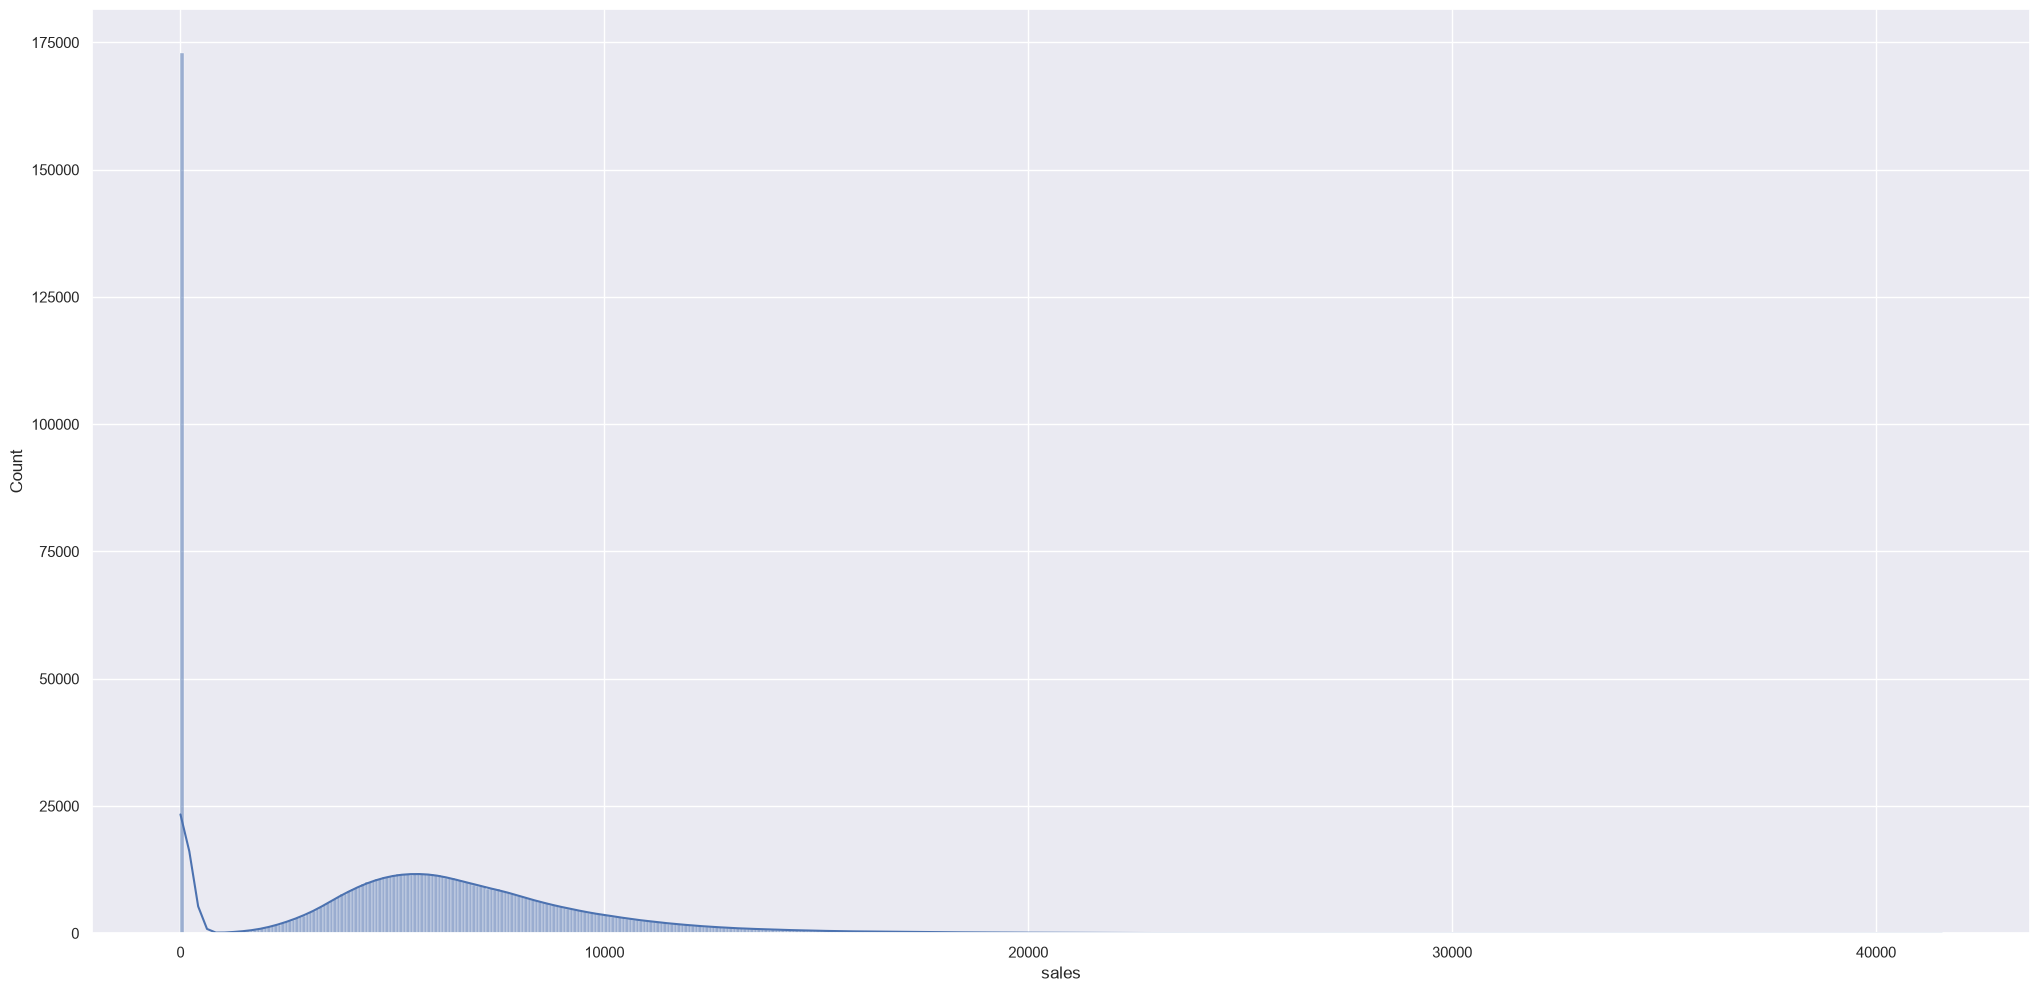

In [23]:
sns.histplot(df1['sales'], kde=True)

<Axes: xlabel='competition_distance', ylabel='Count'>

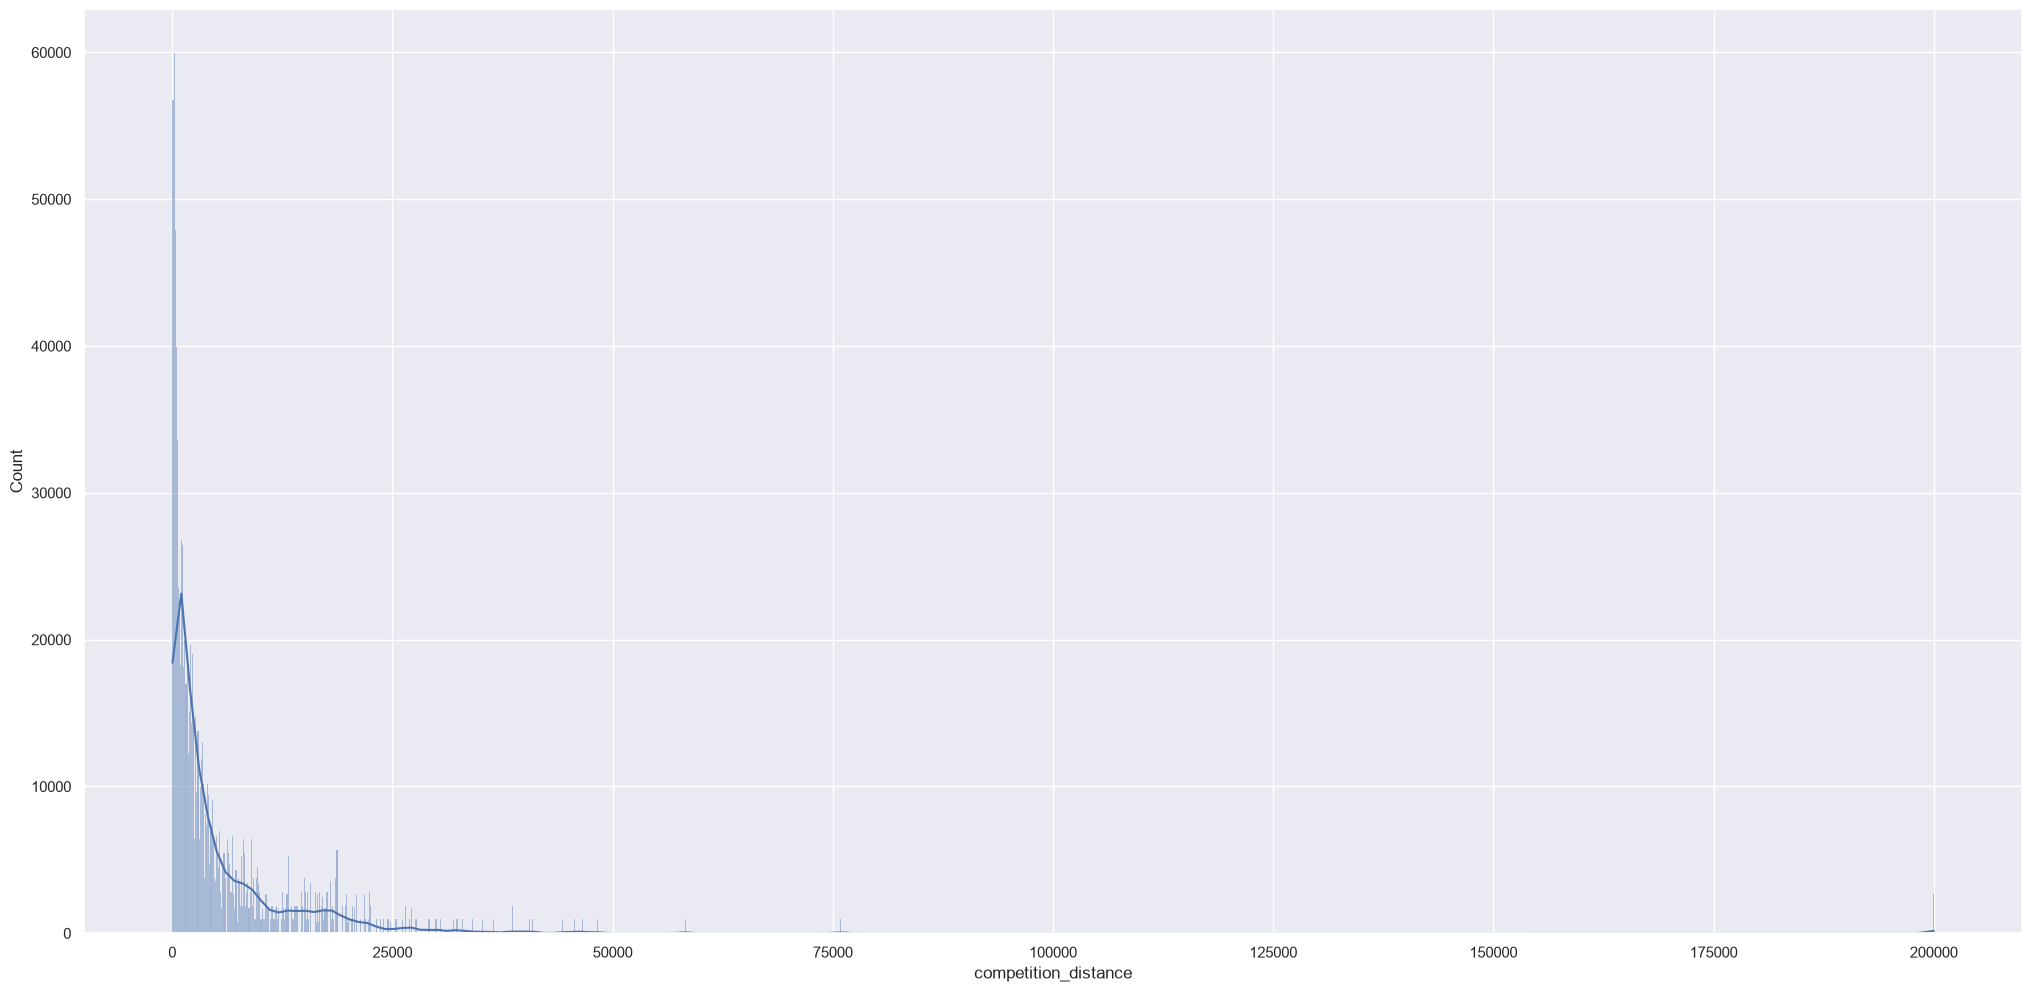

In [24]:
sns.histplot(df1['competition_distance'], kde=True)

### 1.7.2 Categorical Attributes

In [25]:
cat_attributes.apply(lambda x: x.nunique())

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

<Axes: xlabel='assortment', ylabel='sales'>

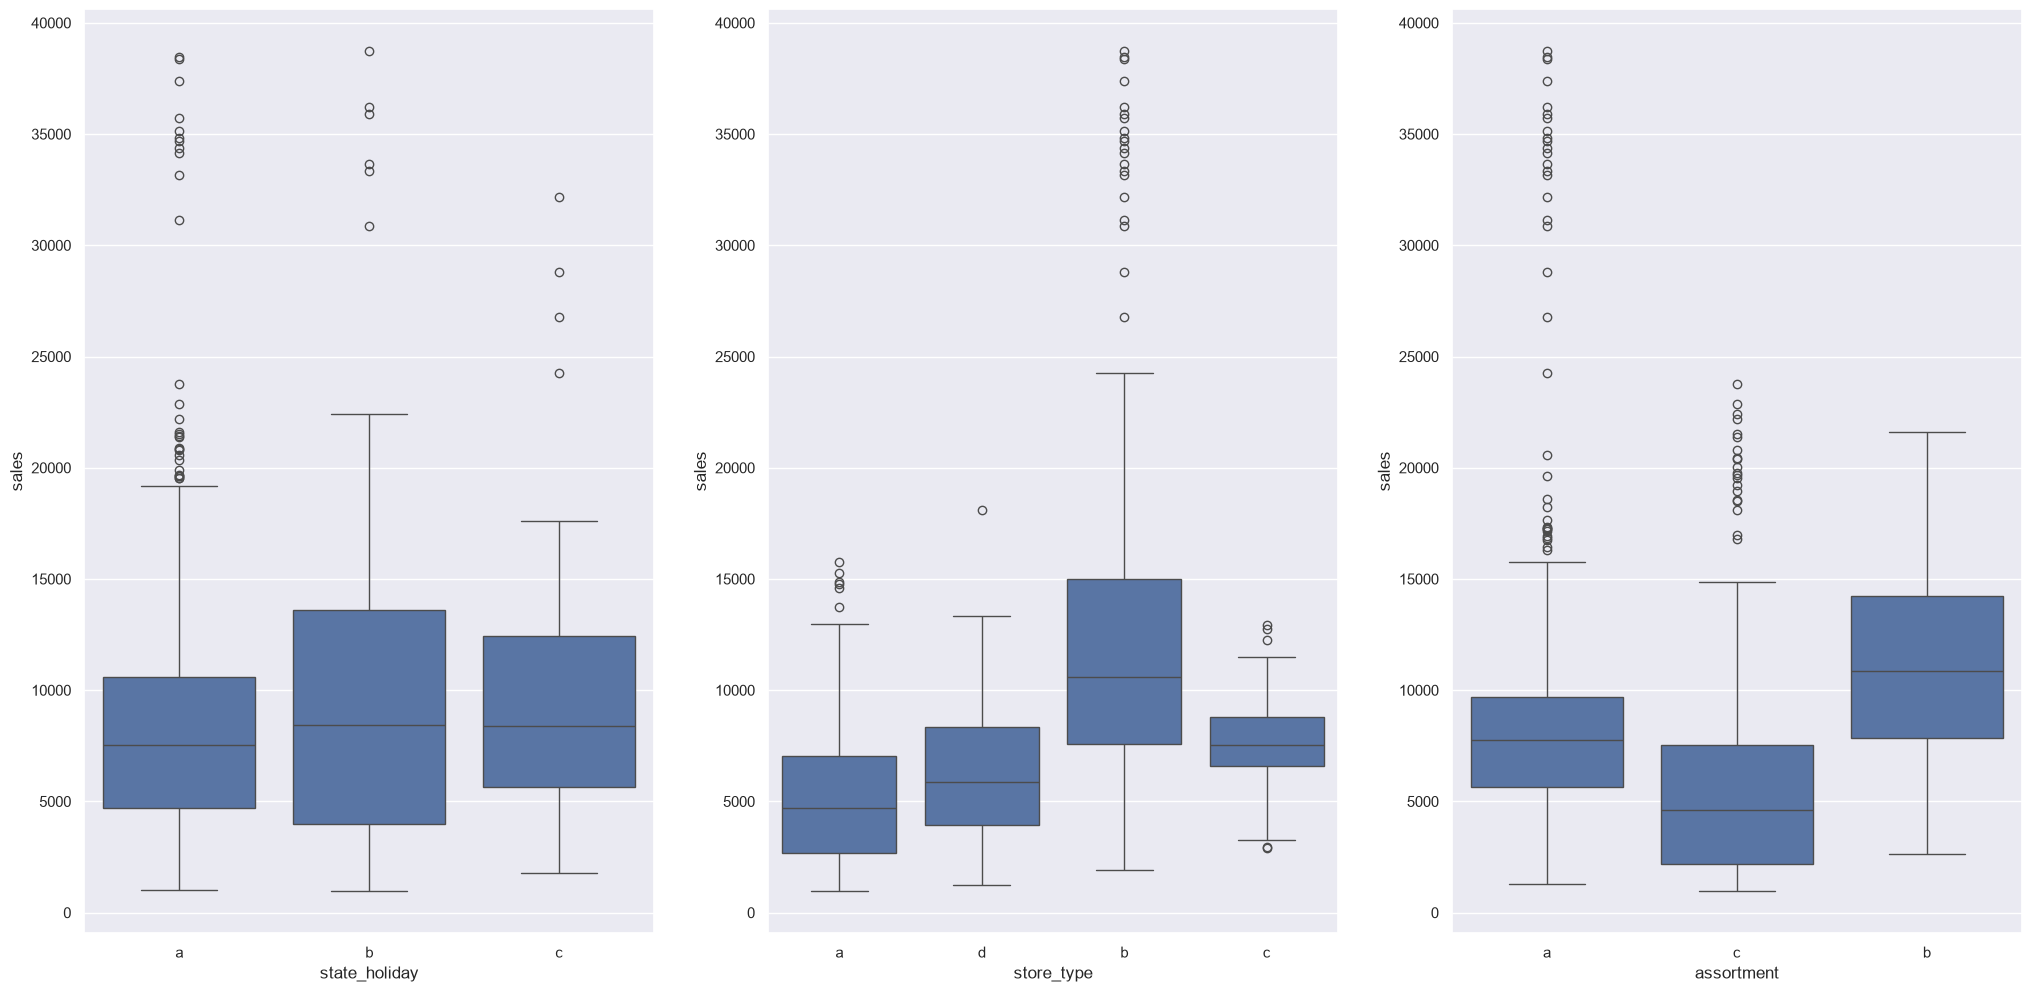

In [26]:
aux1 = df1[(df1['sales']>0) & (df1['state_holiday']!='0')]
# col, lin, posição do gráfico
plt.subplot(1,3,1)
sns.boxplot(x='state_holiday', y='sales', data=aux1)

plt.subplot(1,3,2)
sns.boxplot(x='store_type', y='sales', data=aux1)

plt.subplot(1,3,3)
sns.boxplot(x='assortment', y='sales', data=aux1)

## Elementos de mapa mental de hipóteses:

1) Fenômeno: o que está tentando medir ou modelar (resultado = y).

2) Agentes: agentes que impactam seu fenômeno (features = x)

3) Atributos do agente: características dos atributos.

## Hipóteses são geradas por:

1) Surpresa: insight com hipóteses não analisadas.

2) Teste de crença: verificar se a contraposição da crença é validada ou não.

# 2.0 Feature Engineering

## Mapa Mental de Hipóteses

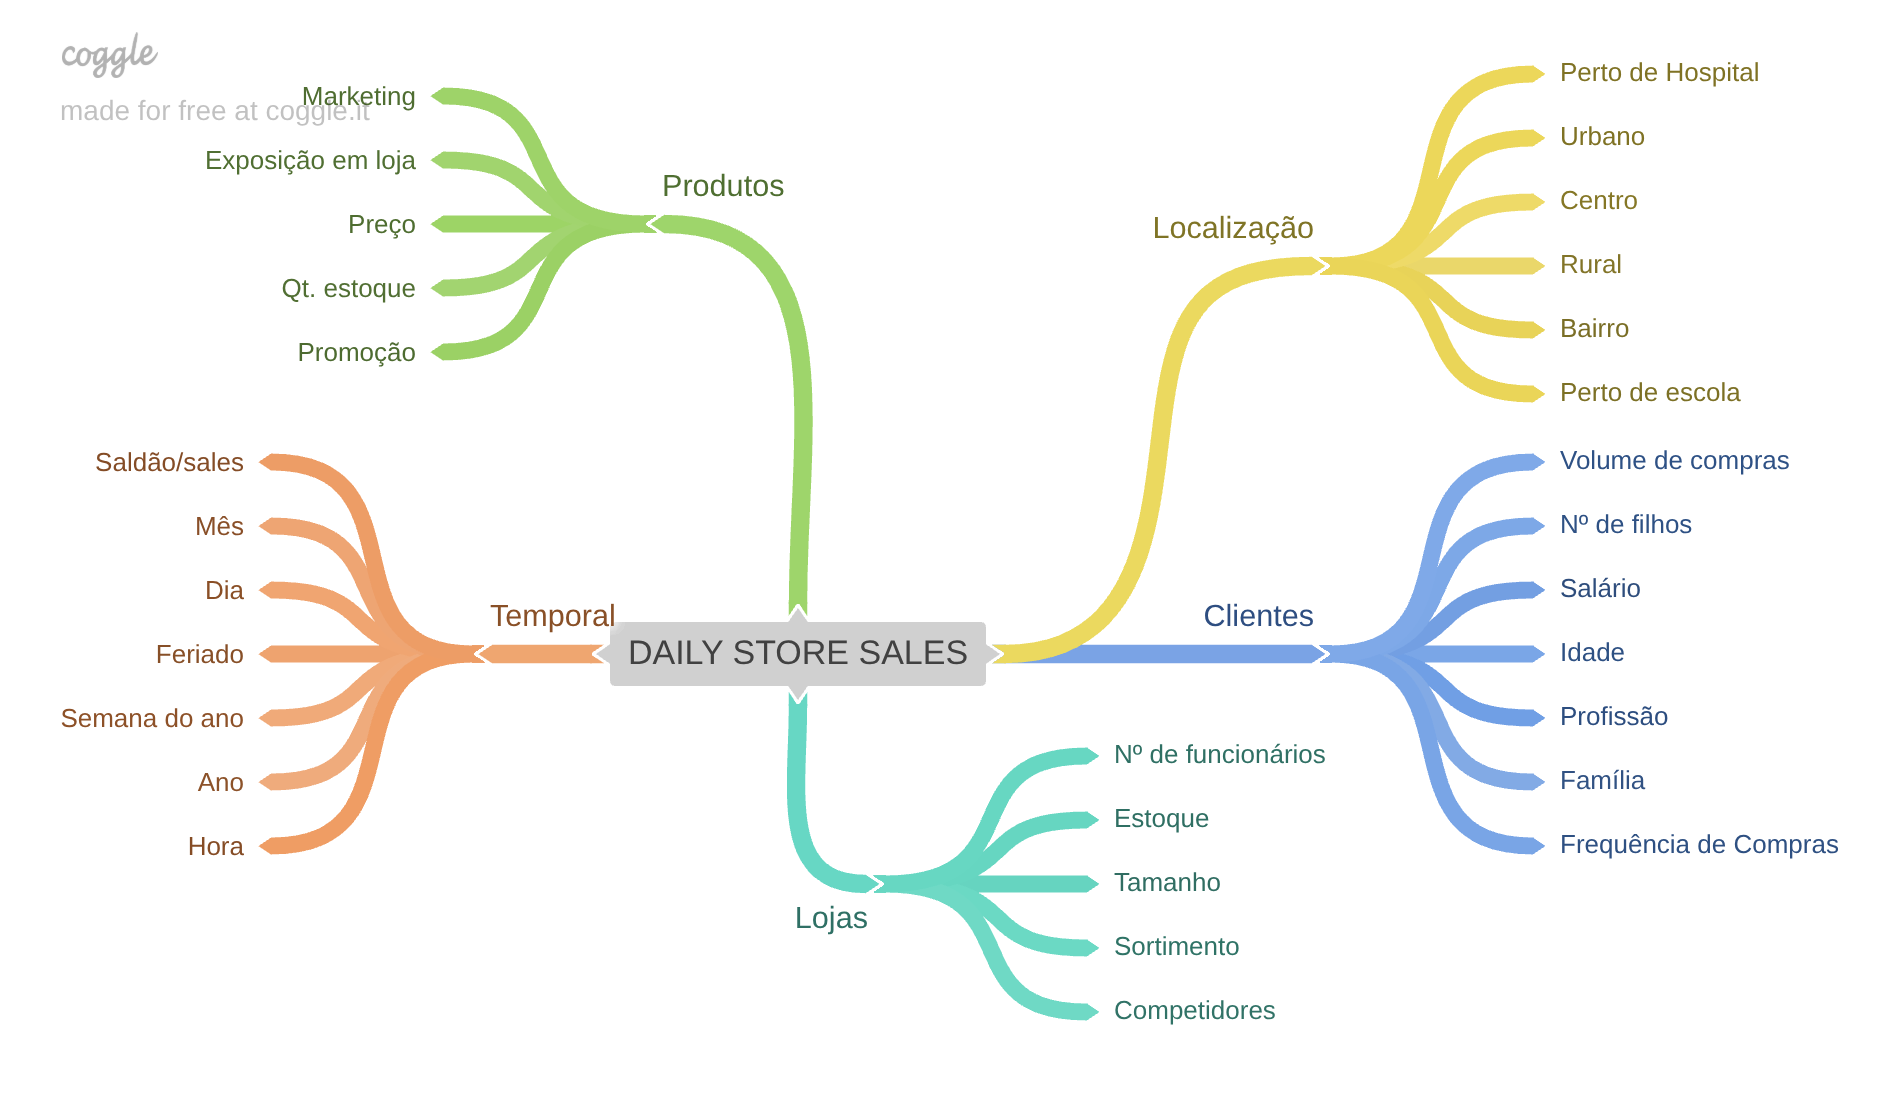

In [27]:
image('c:/repos/Rossmann_Project/img/MindmapHypothesis.png')

## 2.1 Criação das hipóteses

### 2.1.1 Hipóteses Loja

**1** Lojas com maior quadro de funcionários vendem mais.

**2** Lojas com maior capacidade de estoque vendem mais.

**3** Lojas com maior porte vendem mais.

**4** Lojas com maior sortimento vendem mais.

**4** Lojas com competidores mais próximos vendem menos.

**6** Lojas com competidores a mais tempo vendem mais.

### 2.1.2 Hipóteses Produto

**1** Lojas com maior investimento em marketing vendem mais.

**2** Lojas com maior exposição de produtos vendem mais.

**3** Lojas com menores preços vendem mais.

**4** Lojas com promoções mais agressivas (descontos amiores) vendem mais.

**5** Lojas com promoções ativas por mais tempo vendem mais.

**6** Lojas com mais dias de promoção vendem mais.

**7** Lojas com promoções consecutivas vendem mais.

### 2.1.3 Hipóteses Temporal

**1** Lojas abertas nos feriados de Natal vendem mais.

**2** Lojas ao longo dos anos vendem mais.

**3** Lojas vendem mais no segundo semestre do ano.

**4** Lojas vendem mais após o dia 10 de cada mês.

**5** Lojas vendem menos aos finais de semana.

**6** Lojas vendem menos durante os feriados escolares.

## 2.2 Lista final de Hipóteses 

### Hipóteses com dados disponíveis:

**1** Lojas com maior sortimento vendem mais.

**2** Lojas com competidores mais próximos vendem menos.

**3** Lojas com competidores a mais tempo vendem mais.

**4.** Lojas com promoções ativas por mais tempo vendem mais.

**5.** Lojas com mais dias de promoção vendem mais.

**6.** Lojas com mais promoções consecutivas vendem mais.

**7** Lojas abertas nos feriados de Natal vendem mais.

**8** Lojas ao longo dos anos vendem mais.

**9** Lojas vendem mais no segundo semestre do ano.

**10** Lojas vendem mais após o dia 10 de cada mês.

**11** Lojas vendem menos aos finais de semana.

**12** Lojas vendem menos durante os feriados escolares.

### Feature Engineering

In [28]:
df2 = df1.copy()

In [29]:
df2.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month             int64
competition_open_since_year              int64
promo2                                   int64
promo2_since_week                        int64
promo2_since_year                        int64
promo_interval                             str
month_map                                  str
is_promo                                 int64
dtype: object

In [30]:
# year
df2['year'] = df2['date'].dt.year

# month
df2['month'] = df2['date'].dt.month

# day
df2['day'] = df2['date'].dt.day

# week of year
df2['week_year'] = df2['date'].dt.isocalendar().week

# year week
df2['year_week'] = df2['date'].dt.strftime( '%Y-%W' )

from datetime import datetime

# competition since axis=0 (verticalmente, coluna por coluna) e axis=1 (horizontalmente, linha por linha)
df2['competition_since'] = df2.apply(
    lambda x: datetime(
        year=int(x['competition_open_since_year']),
        month=int(x['competition_open_since_month']),
        day=1
    ),
    axis=1
)

# competition since
df2['competition_since'] = df2.apply( 
    lambda x: datetime( year=x['competition_open_since_year'], 
                       month=x['competition_open_since_month'],
                       day=1 
                       ), 
    axis=1 
    )

# competition_time_month ou tempo da competição em meses
df2['competition_time_month'] = ( 
    ( df2['date'] - df2['competition_since'] )/30 ).apply( lambda x: x.days
                                                          ).astype( int )
                                                                                          
# promo since
df2['promo_since'] = df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str)
from datetime import datetime, timedelta

df2['promo_since'] = df2['promo_since'].apply(
    lambda x: datetime.strptime(x + '-1', '%Y-%W-%w') - timedelta(days=7)
)
df2['promo_time_week'] = ((df2['date'] - df2['promo_since']) /7).apply(lambda x: x.days).astype(int)

# assortment
df2['assortment'] = df2['assortment'].apply( lambda x: 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended' )

# state holiday
df2['state_holiday'] = df2['state_holiday'].apply( lambda x: 'public_holiday' if x == 'a' else 'easter_holiday' if x == 'b' else 'christmas' if x == 'c' else 'regular_day' )

In [31]:
df2[['year', 'month','day','week_year','year_week', 'competition_since', 'competition_time_month','promo_since','promo_time_week','assortment','state_holiday']].head().T


,0,1,2,3,4
year,2015,2015,2015,2015,2015
month,7,7,7,7,7
day,31,31,31,31,31
week_year,31,31,31,31,31
year_week,2015-30,2015-30,2015-30,2015-30,2015-30
competition_since,2008-09-01 00:00:00,2007-11-01 00:00:00,2006-12-01 00:00:00,2009-09-01 00:00:00,2015-04-01 00:00:00
competition_time_month,84,94,105,71,4
promo_since,2015-07-27 00:00:00,2010-03-22 00:00:00,2011-03-28 00:00:00,2015-07-27 00:00:00,2015-07-27 00:00:00
promo_time_week,0,279,226,0,0
assortment,basic,basic,basic,extended,basic


In [32]:
df2.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
customers                       0
open                            0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
promo_interval                  0
month_map                       0
is_promo                        0
year                            0
month                           0
day                             0
week_year                       0
year_week                       0
competition_since               0
competition_time_month          0
promo_since                     0
promo_time_week                 0
dtype: int64

# 3.0 Filtragem de Variáveis

In [33]:
df3 = df2.copy()

## 3.1 Filtragem das Linhas

In [34]:
df3 = df2[(df2['open'] != 0) & (df2['sales'] > 0)]

## 3.2 Seleção das Colunas

In [35]:
cols_drop = ['customers', 'open', 'promo_interval', 'month_map']
df3 = df3.drop(columns=cols_drop)

In [36]:
df3.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week'],
      dtype='str')

In [37]:
df3.head()

,store,day_of_week,date,sales,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,month,day,week_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,1,regular_day,1,c,basic,1270.0,9,2008,0,31,2015,0,2015,7,31,31,2015-30,2008-09-01,84,2015-07-27,0
1,2,5,2015-07-31,6064,1,regular_day,1,a,basic,570.0,11,2007,1,13,2010,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,1,regular_day,1,a,basic,14130.0,12,2006,1,14,2011,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1,regular_day,1,c,extended,620.0,9,2009,0,31,2015,0,2015,7,31,31,2015-30,2009-09-01,71,2015-07-27,0
4,5,5,2015-07-31,4822,1,regular_day,1,a,basic,29910.0,4,2015,0,31,2015,0,2015,7,31,31,2015-30,2015-04-01,4,2015-07-27,0


In [38]:
df3.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
is_promo                        0
year                            0
month                           0
day                             0
week_year                       0
year_week                       0
competition_since               0
competition_time_month          0
promo_since                     0
promo_time_week                 0
dtype: int64

# 4.0 Análise Exploratória dos Dados (EDA)

In [39]:
df4 = df3.copy()

## 4.1 Análise Univariada

In [40]:
df4.columns


Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week'],
      dtype='str')

### 4.1.1 Response Variable

<Axes: xlabel='sales', ylabel='Count'>

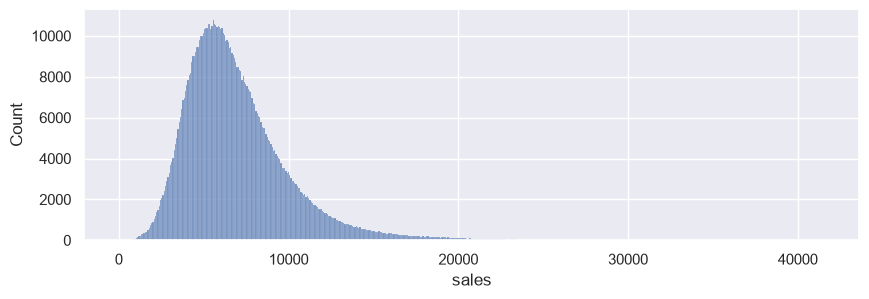

In [41]:
plt.figure(figsize=(10,3))
sns.histplot( df4['sales'], kde=False  )

### 4.1.2 Numerical Variable

array([[<Axes: title={'center': 'store'}>,
        <Axes: title={'center': 'day_of_week'}>,
        <Axes: title={'center': 'sales'}>,
        <Axes: title={'center': 'customers'}>],
       [<Axes: title={'center': 'open'}>,
        <Axes: title={'center': 'promo'}>,
        <Axes: title={'center': 'school_holiday'}>,
        <Axes: title={'center': 'competition_distance'}>],
       [<Axes: title={'center': 'competition_open_since_month'}>,
        <Axes: title={'center': 'competition_open_since_year'}>,
        <Axes: title={'center': 'promo2'}>,
        <Axes: title={'center': 'promo2_since_week'}>],
       [<Axes: title={'center': 'promo2_since_year'}>,
        <Axes: title={'center': 'is_promo'}>, <Axes: >, <Axes: >]],
      dtype=object)

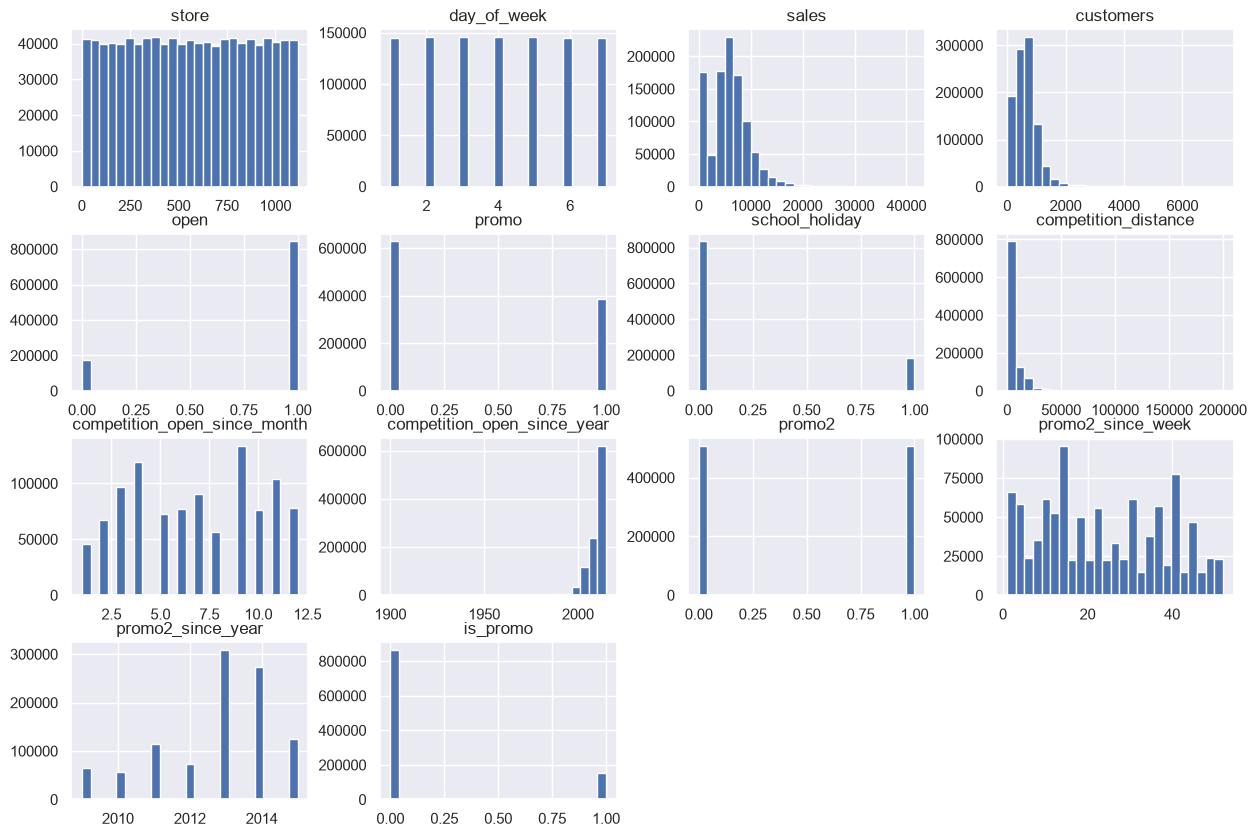

In [42]:
num_attributes.hist(bins=25, figsize=(15,10))

### 4.1.3 Categorical Variable

In [43]:
cat_attributes.head()

,state_holiday,store_type,assortment,promo_interval,month_map
0,0,c,a,0,Jul
1,0,a,a,"Jan,Apr,Jul,Oct",Jul
2,0,a,a,"Jan,Apr,Jul,Oct",Jul
3,0,c,c,0,Jul
4,0,a,a,0,Jul


In [44]:
# contagem de linhas com cada resposta dessa variável
df4['assortment'].drop_duplicates()

0         basic
3      extended
258       extra
Name: assortment, dtype: str

<Axes: xlabel='sales', ylabel='Density'>

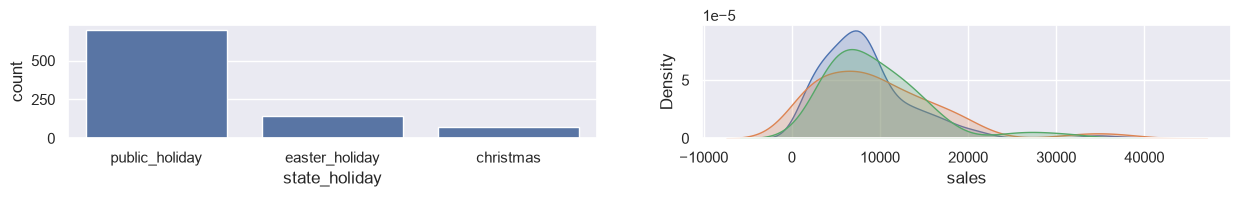

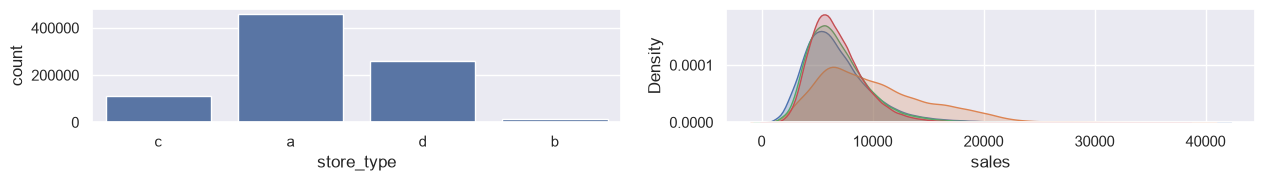

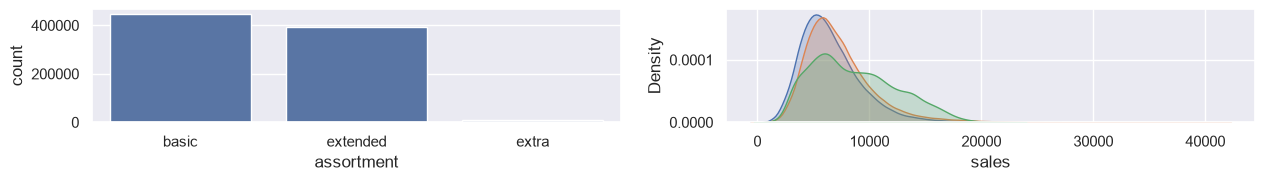

In [45]:
# state_holiday
plt.figure(figsize=(15,5))
plt.subplot( 3, 2, 1 )
a = df4[df4['state_holiday'] != 'regular_day']
sns.countplot(a['state_holiday'].reset_index() ,x='state_holiday')

plt.subplot( 3, 2, 2 )
sns.kdeplot( df4[df4['state_holiday'] == 'public_holiday']['sales'], label='public_holiday', fill=True )
sns.kdeplot( df4[df4['state_holiday'] == 'easter_holiday']['sales'], label='easter_holiday', fill=True )
sns.kdeplot( df4[df4['state_holiday'] == 'christmas']['sales'], label='christmas', fill=True )

# store_type
plt.figure(figsize=(15,5))
plt.subplot( 3, 2, 3 )
sns.countplot(df4['store_type'].reset_index() ,x='store_type')

plt.subplot( 3, 2, 4 )
sns.kdeplot( df4[df4['store_type'] == 'a']['sales'], label='a', fill=True )
sns.kdeplot( df4[df4['store_type'] == 'b']['sales'], label='b', fill=True )
sns.kdeplot( df4[df4['store_type'] == 'c']['sales'], label='c', fill=True )
sns.kdeplot( df4[df4['store_type'] == 'd']['sales'], label='d', fill=True )

# assortment
plt.figure(figsize=(15,5))
plt.subplot( 3, 2, 5 )
sns.countplot(df4['assortment'].reset_index() ,x='assortment')

plt.subplot( 3, 2, 6 )
sns.kdeplot( df4[df4['assortment'] == 'basic']['sales'], label='basic', fill=True )
sns.kdeplot( df4[df4['assortment'] == 'extended']['sales'], label='extended', fill=True )
sns.kdeplot( df4[df4['assortment'] == 'extra']['sales'], label='extra', fill=True )

## 4.2 Análise Bivariada

### **H1** Lojas com maior sortimento vendem mais.

**FALSA** Lojas com maior sortimento vendem menos.

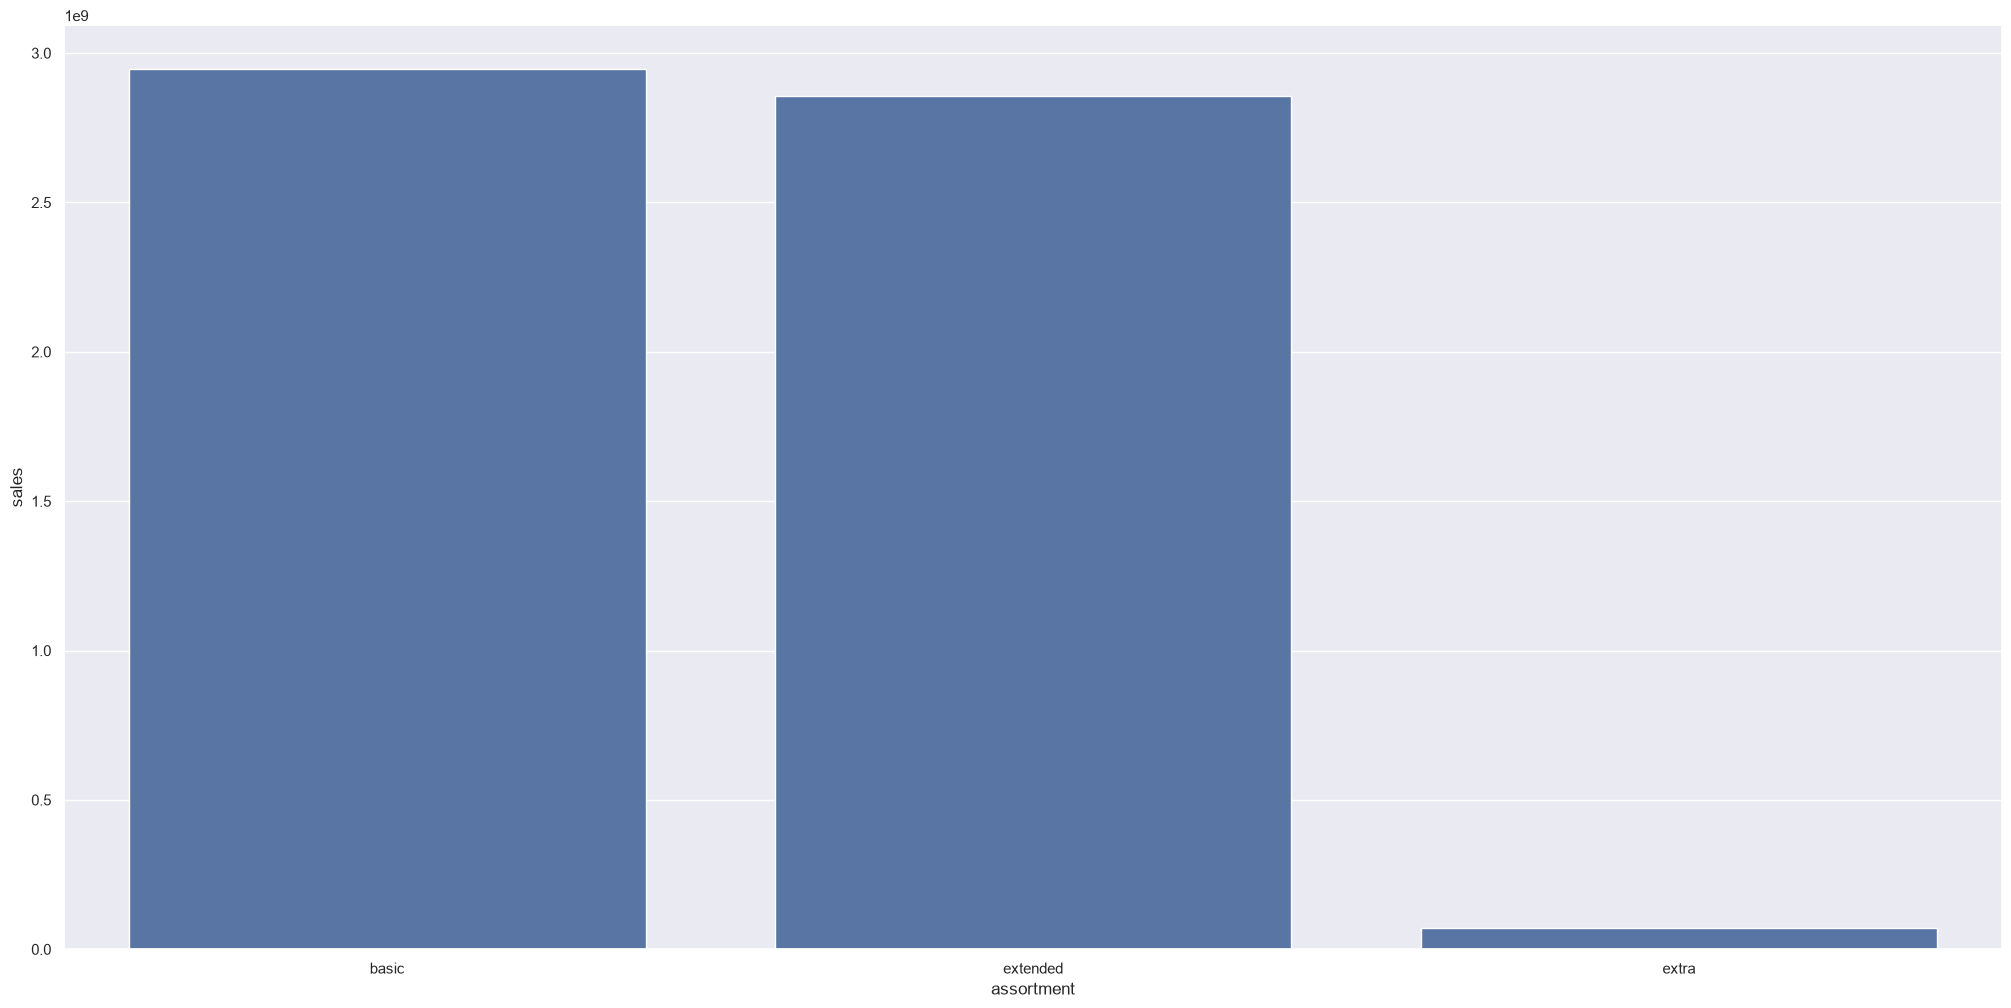

In [46]:
aux1= df4[['assortment', 'sales']].groupby('assortment').sum().reset_index()
sns.barplot(x= 'assortment', y='sales', data=aux1);

<Axes: xlabel='year_week'>

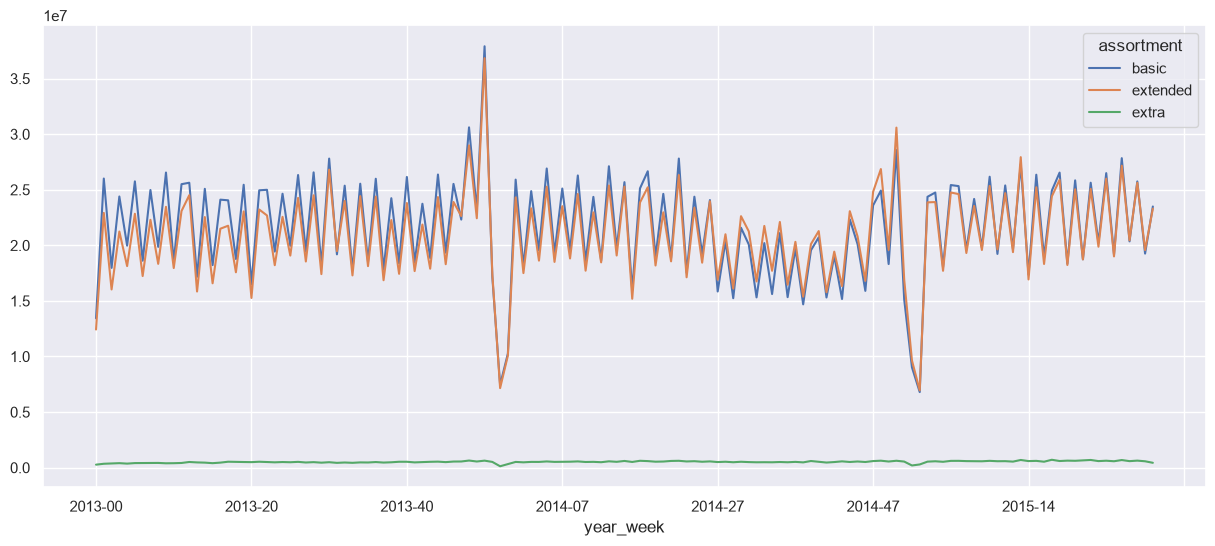

In [47]:
aux2 = df4[['year_week', 'assortment', 'sales']].groupby(['year_week', 'assortment']).sum().reset_index()

aux2.pivot( columns ='assortment' , index ='year_week', values='sales').plot(figsize=(15, 6))

<Axes: xlabel='year_week'>

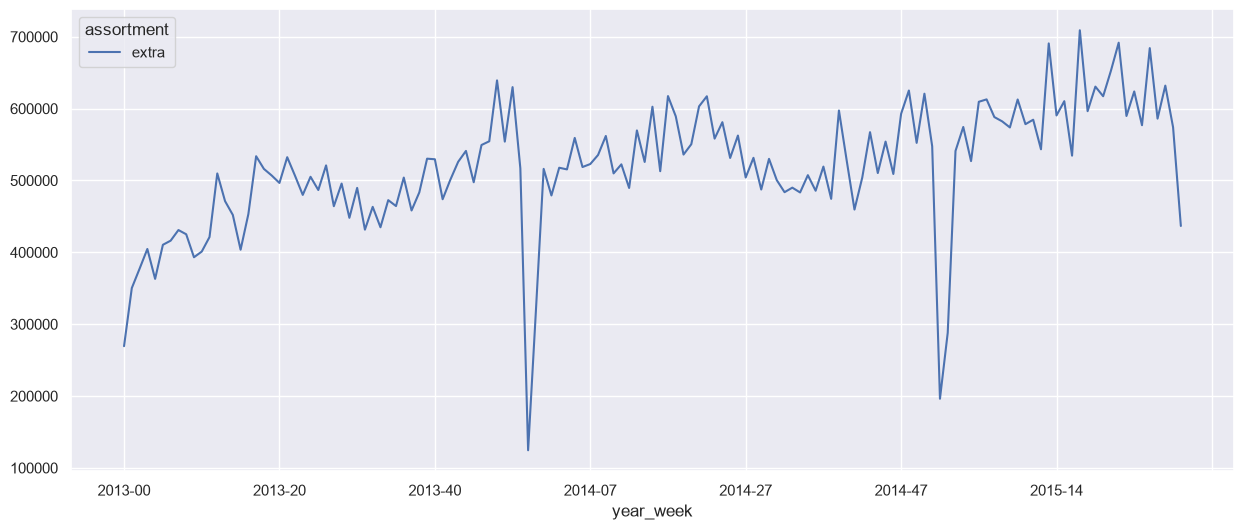

In [48]:
aux3 = aux2[aux2['assortment']=='extra']
aux3.pivot(columns ='assortment' , index ='year_week', values='sales').plot(figsize=(15, 6))

### **H2** Lojas com competidores mais próximos vendem menos.

**FALSA** Lojas com competidores mais próximos vendem mais.

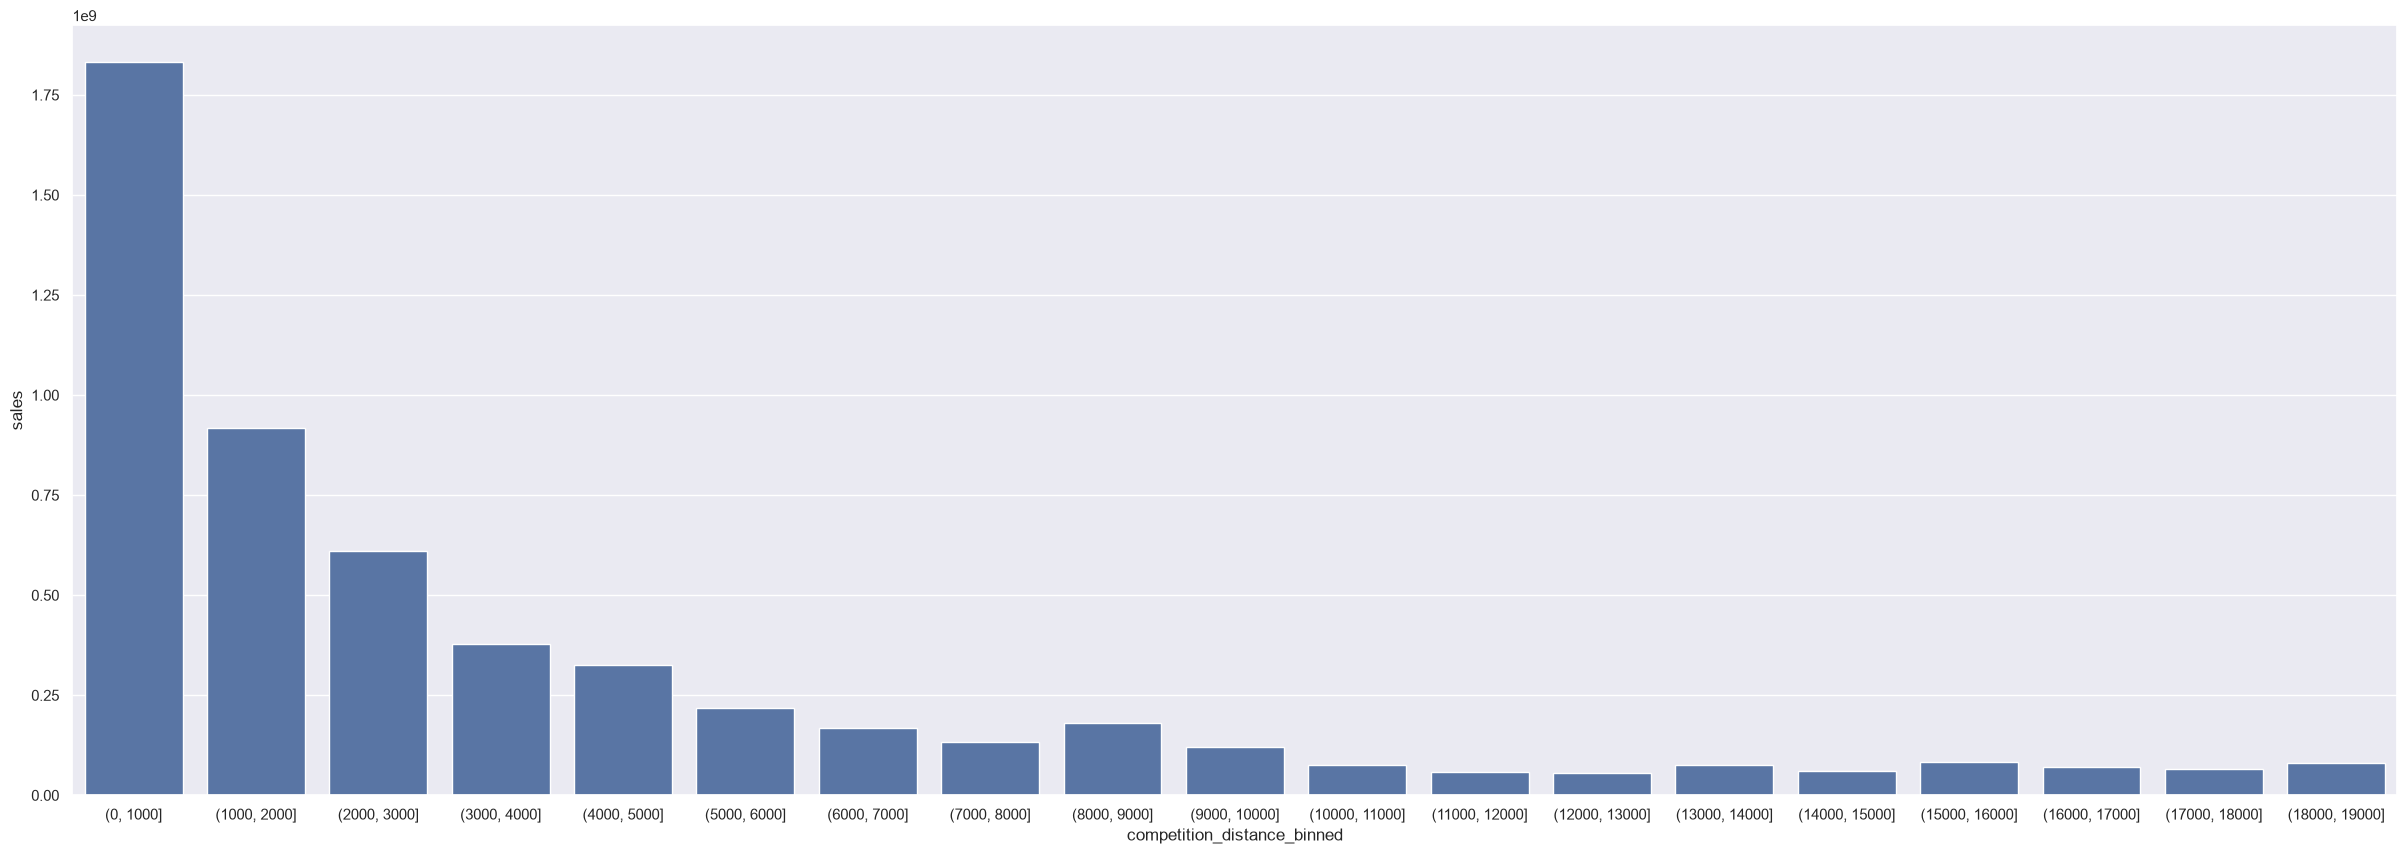

In [49]:
# Um par de colchetes → "quero a coluna". Dois pares de colchetes → "quero uma tabela contendo essa(s) coluna(s)".

aux5 = df4[['competition_distance','sales']].groupby('competition_distance').sum().reset_index()

bins = list(np.arange(0,20000,1000))
aux5['competition_distance_binned']=pd.cut(aux5['competition_distance'],bins=bins)

aux6 = aux5[['competition_distance_binned','sales']].groupby('competition_distance_binned').sum().reset_index()
plt.figure(figsize=(30, 10))
sns.barplot(x='competition_distance_binned', y='sales',data=aux6);

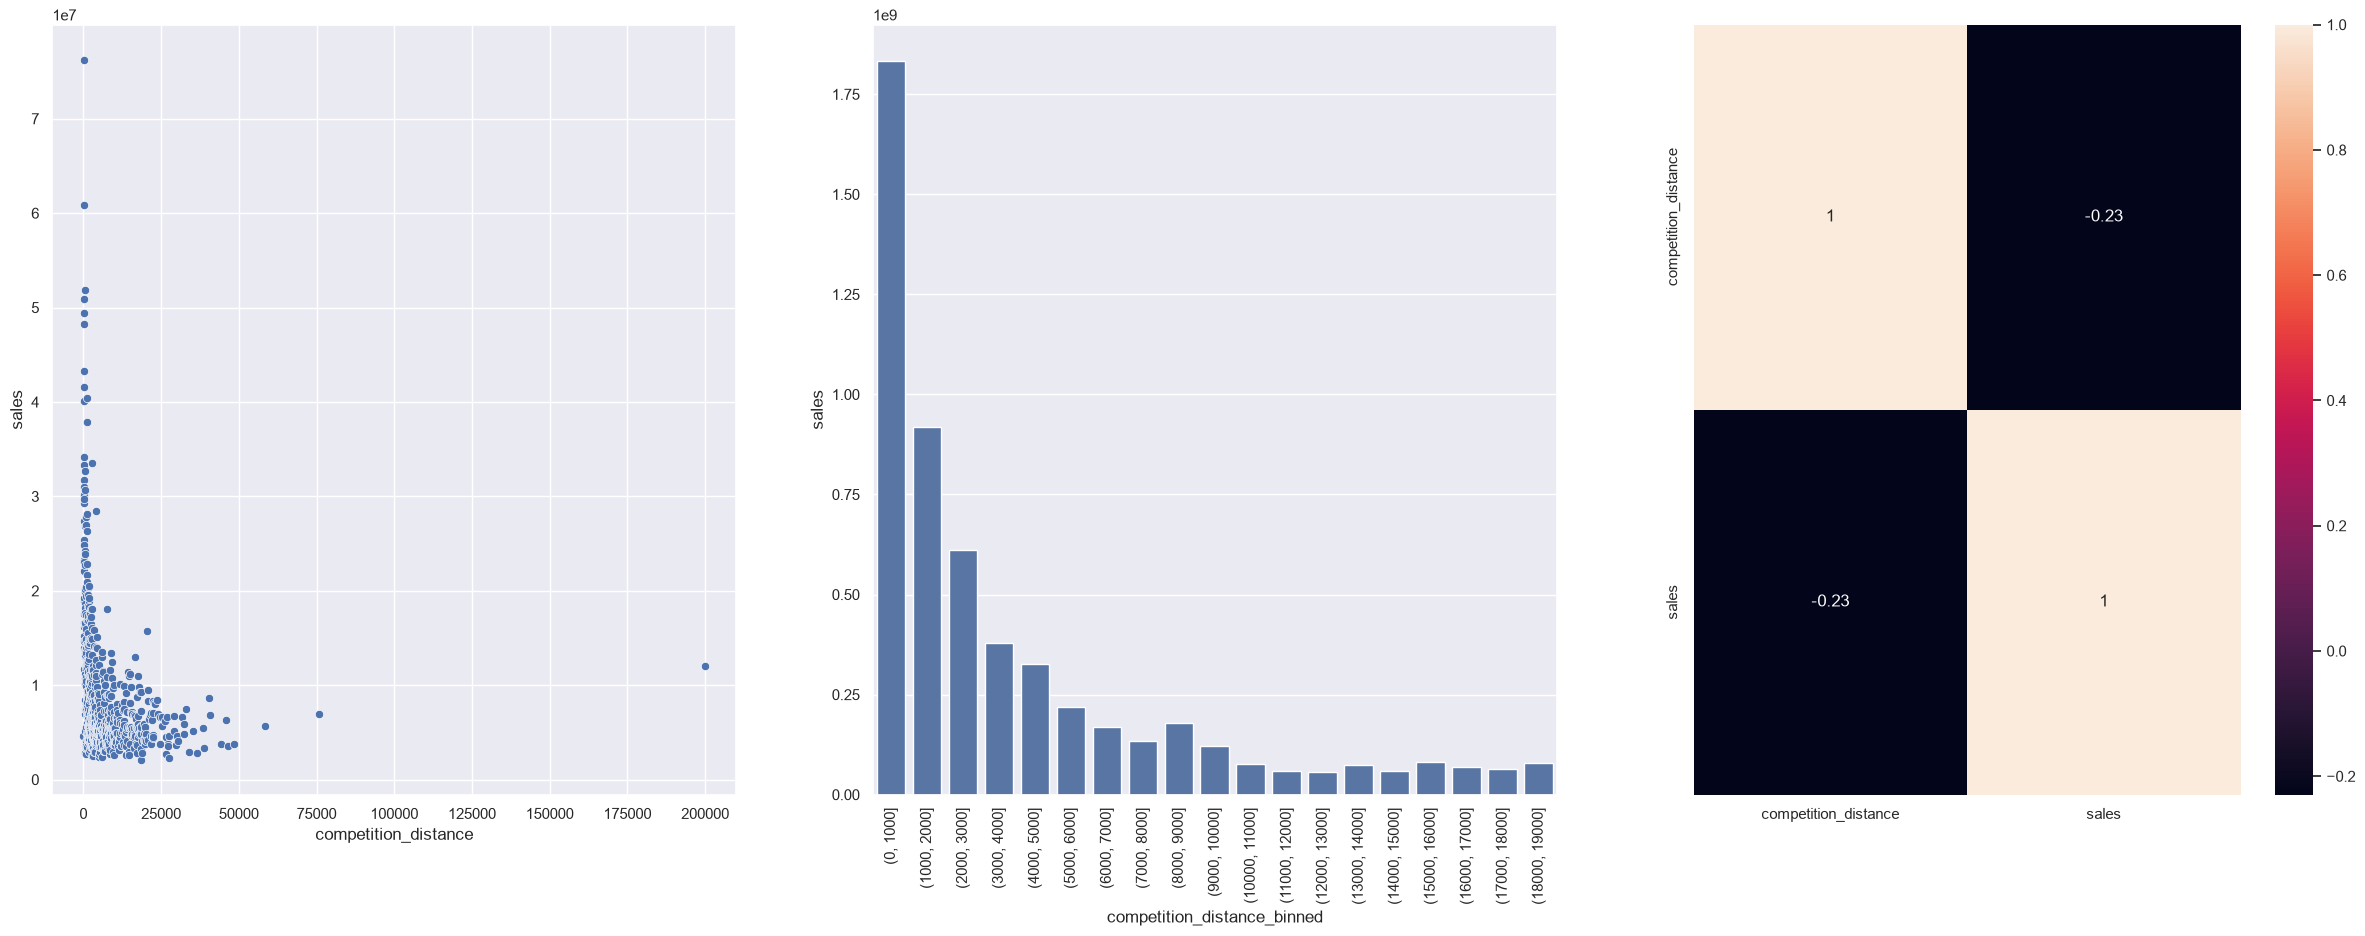

In [50]:
plt.figure(figsize=(30, 10))
plt.subplot(1,3,1)
sns.scatterplot(x='competition_distance', y='sales', data=aux5);

plt.subplot(1,3,2)
sns.barplot(x='competition_distance_binned', y='sales',data=aux6)
plt.xticks(rotation=90);

# Correlação: quanto mais próximo de zero, mais fraca é a correlação.
plt.subplot(1,3,3)
sns.heatmap(aux5.select_dtypes(include=np.number).corr(), annot=True);

### **H3** Lojas com competidores a mais tempo vendem mais.

**FALSA** Lojas com competidores a mais tempo vendem menos

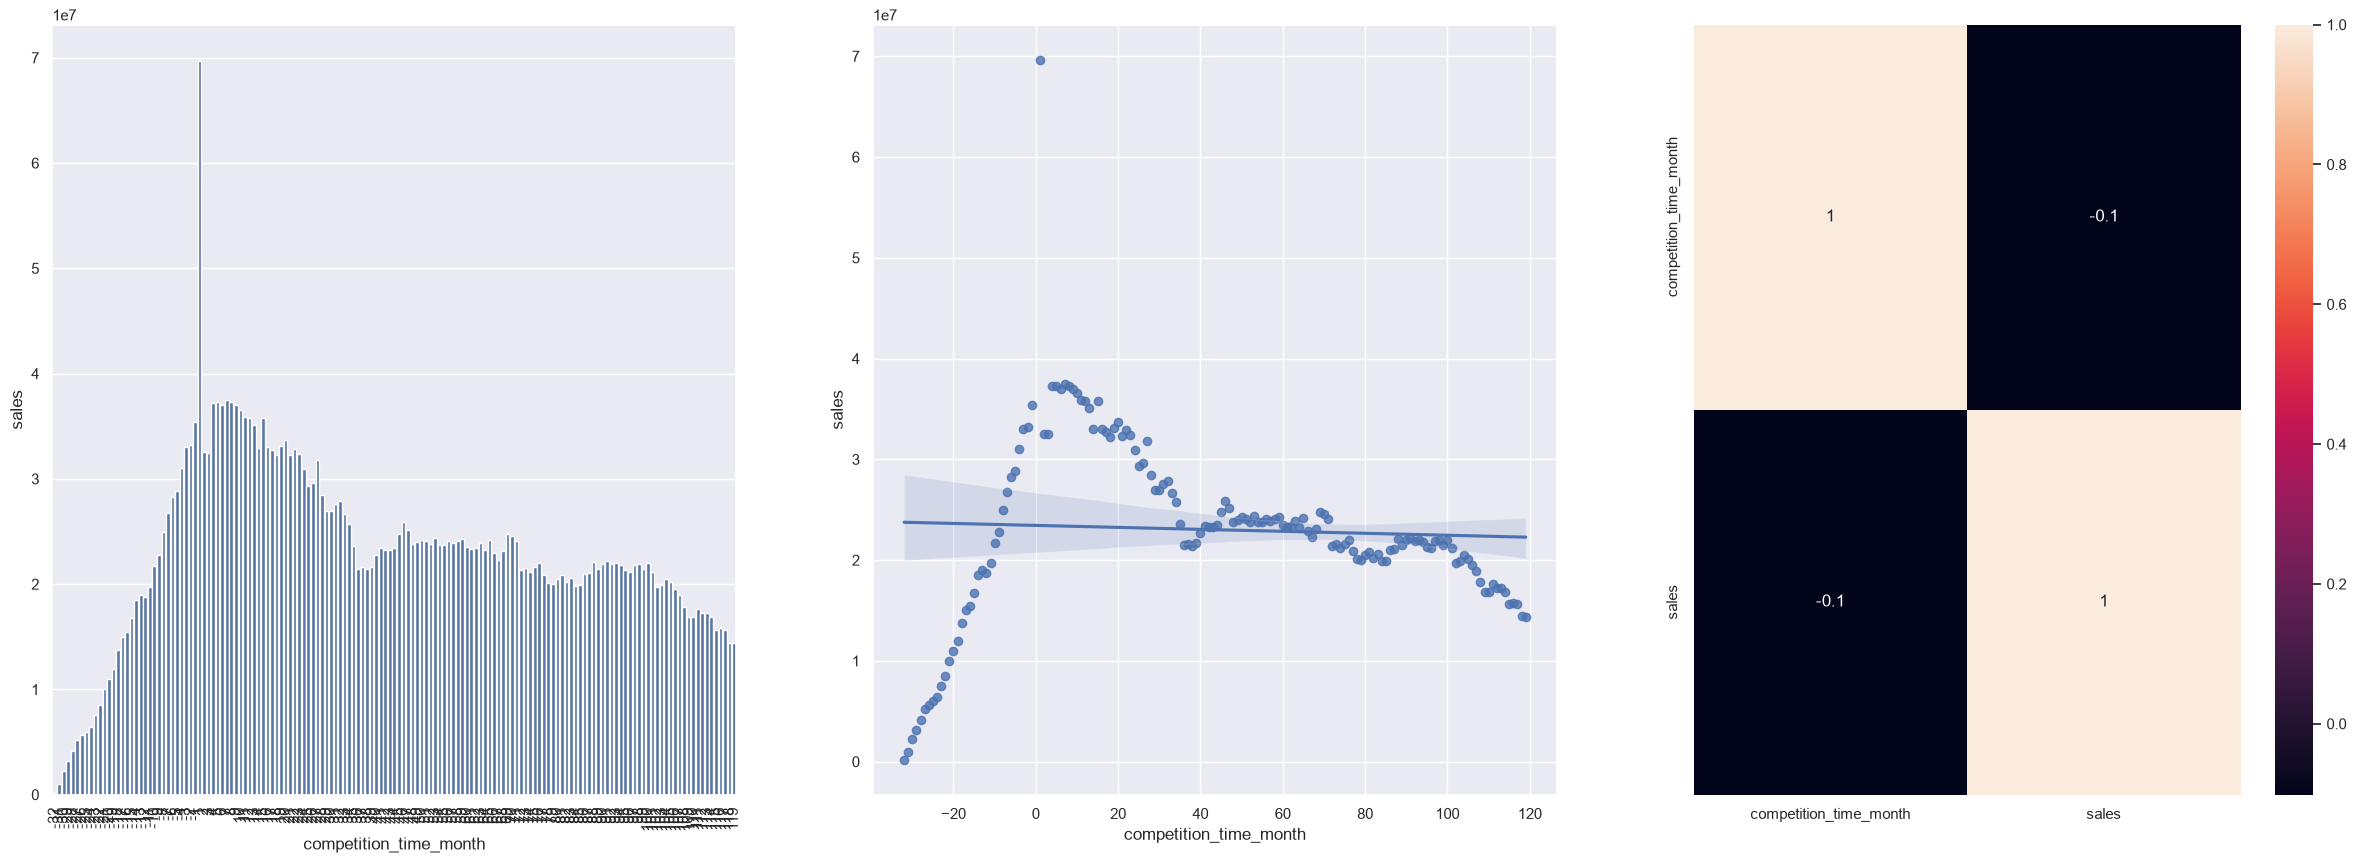

In [51]:
plt.figure(figsize=(30, 10))
plt.subplot(1,3,1)
aux7= df4[['competition_time_month', 'sales']].groupby('competition_time_month').sum().reset_index()
aux8= aux7[(aux7['competition_time_month']<120) & (aux7['competition_time_month'] !=0)]
sns.barplot(x='competition_time_month', y='sales', data=aux8)
plt.xticks(rotation=90);

plt.subplot(1, 3, 2)
sns.regplot(x = 'competition_time_month', y = 'sales', data = aux8);

plt.subplot(1, 3, 3)
sns.heatmap(aux7.corr(method='pearson'), annot=True);


### **H4** Lojas com promoções ativas por mais tempo deveriam vender mais.

**FALSA** Lojas vendem menos depois de um certo período de promoção

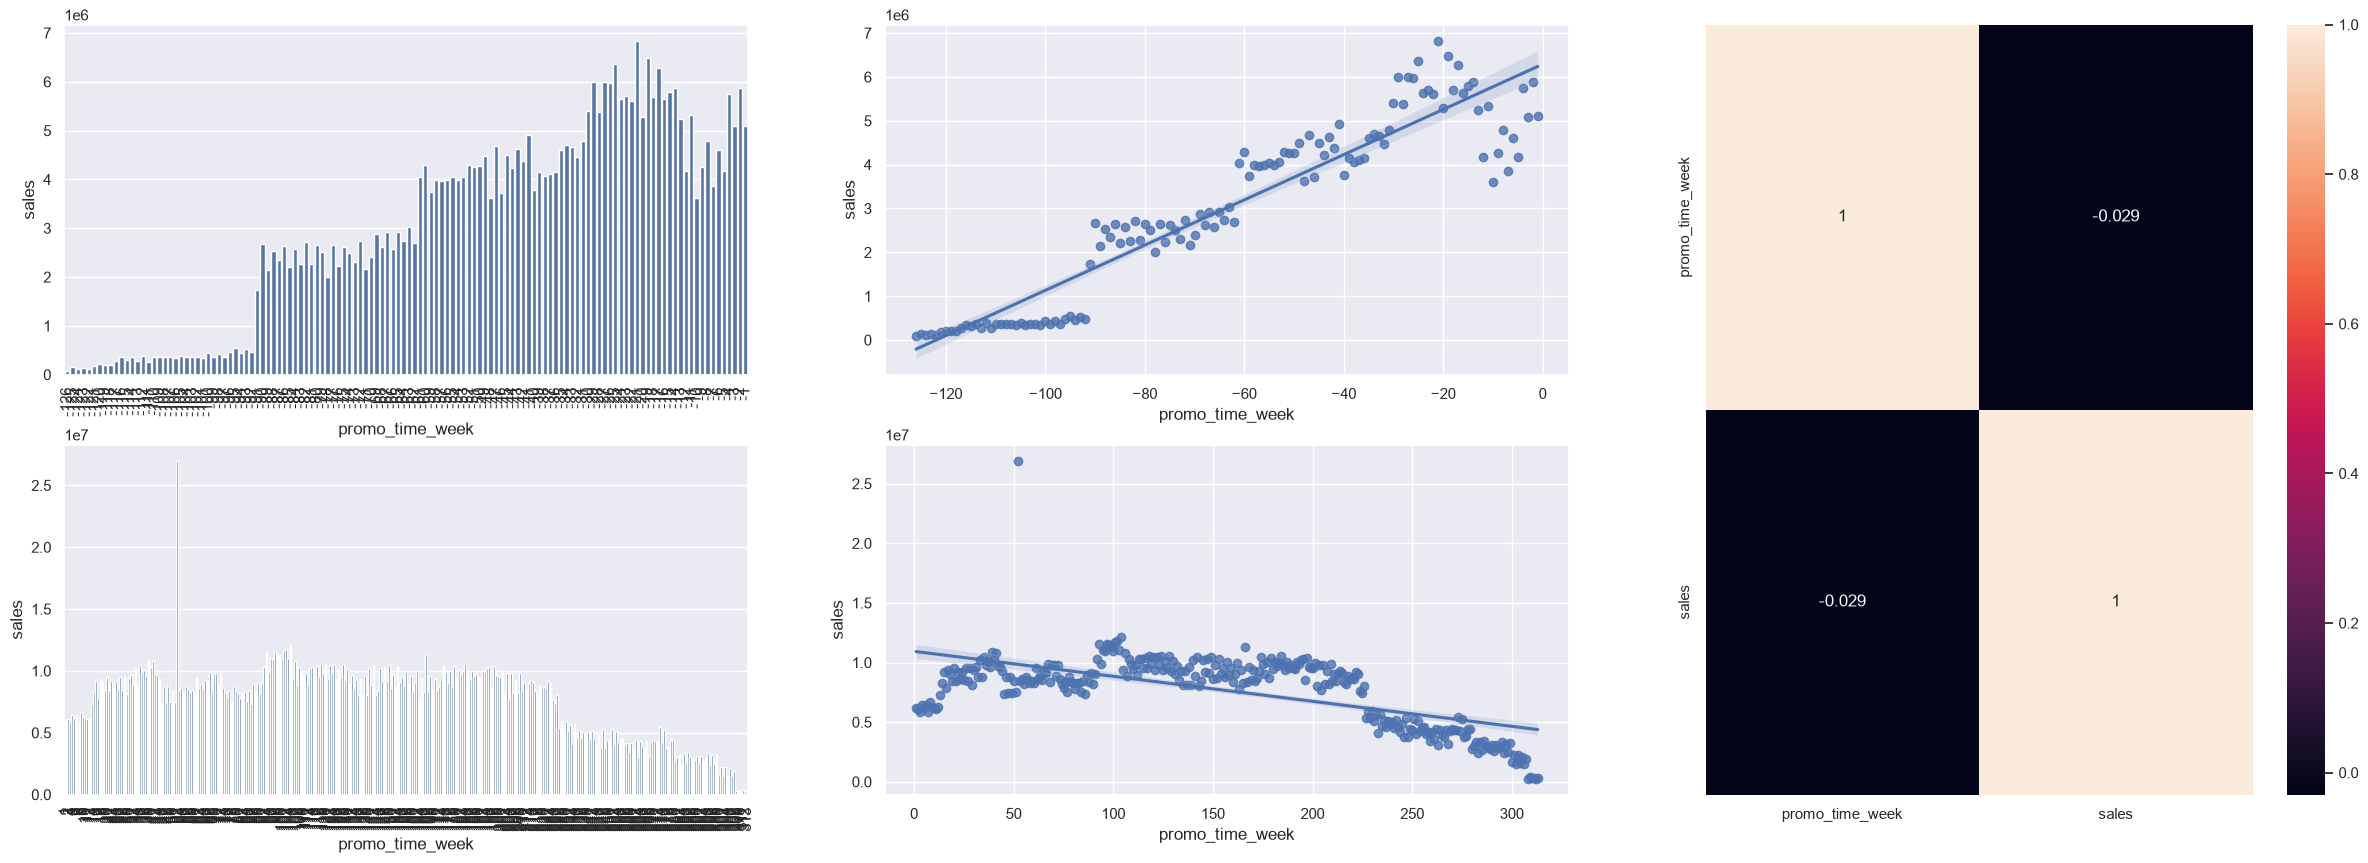

In [52]:
plt.figure(figsize=(30, 10))
aux9 = df4[['promo_time_week', 'sales']].groupby( 'promo_time_week').sum().reset_index()

grid = plt.GridSpec( 2, 3 )

#Período promocional regular
plt.subplot(grid[0,0])
aux11 = aux9[aux9['promo_time_week']<0]
sns.barplot(x='promo_time_week', y='sales', data=aux11)
plt.xticks(rotation = 90) ;

plt.subplot(grid[0,1])
sns.regplot(x='promo_time_week', y='sales', data=aux11)

#Período promocional extendido
plt.subplot(grid[1,0])
aux10 = aux9[aux9['promo_time_week']>0]
sns.barplot(x='promo_time_week', y='sales', data=aux10)
plt.xticks(rotation = 90) ;

plt.subplot(grid[1,1])
sns.regplot(x='promo_time_week', y='sales', data=aux10)

#Correlação quanto mais perto de zero, menor a correlação/influência dessa variável sobre o resultado
plt.subplot(grid[:,2])
sns.heatmap(aux9.corr(method='pearson'), annot=True);

### <s/>**H5.** Lojas com mais dias de promoção deveriam vender mais.</s>

### **H6.** Lojas com mais promoções consecutivas vendem mais.

**FALSA** Lojas com mais promoções consecutivas não vendem mais.

In [53]:
df4[['promo', 'promo2', 'sales']].groupby(['promo','promo2']).sum().reset_index()

,promo,promo2,sales
0,0,0,1482612096
1,0,1,1289362241
2,1,0,1628930532
3,1,1,1472275754


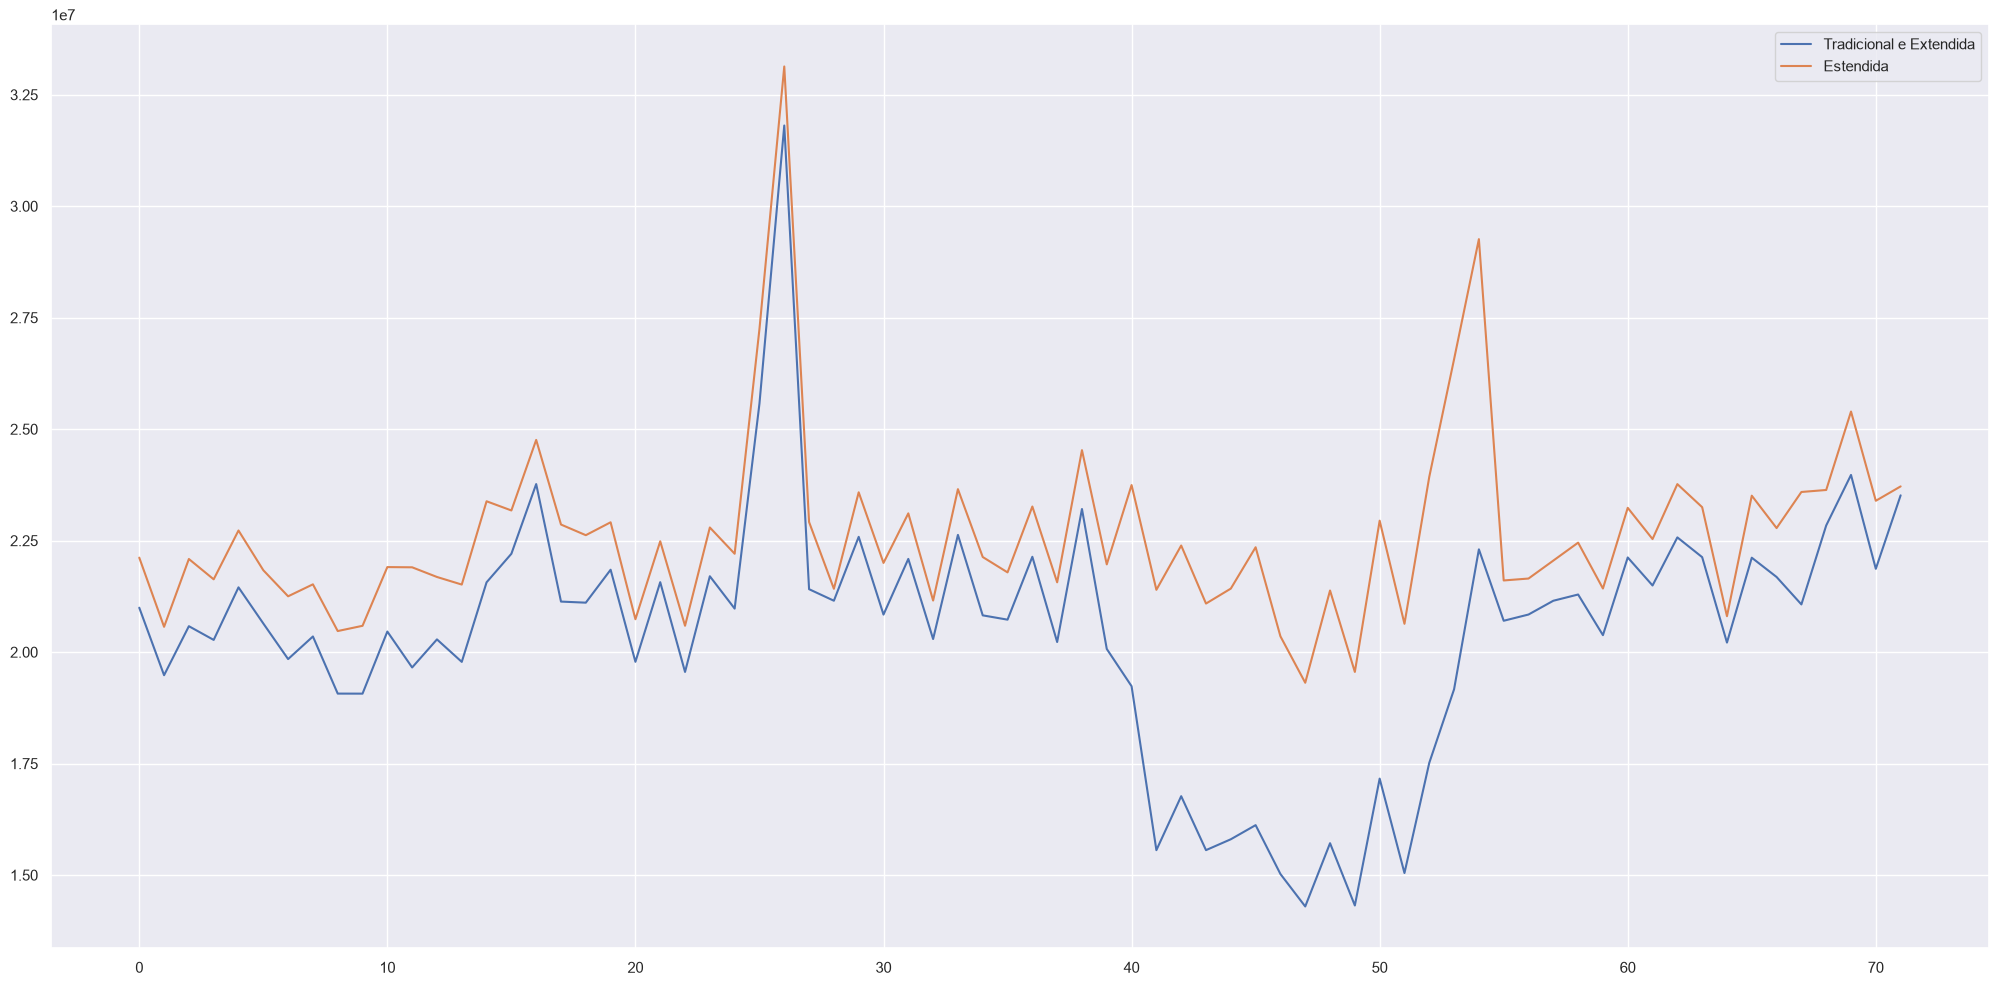

In [54]:
aux12 = df4[(df4['promo']==1) & (df4['promo2']==1)][['year_week','sales']].groupby('year_week').sum().reset_index()
ax = aux12.plot()

aux13 = df4[(df4['promo']==1) & (df4['promo2']==0)][['year_week','sales']].groupby('year_week').sum().reset_index()
aux13.plot(ax=ax)

ax.legend(labels=['Tradicional e Extendida', 'Estendida']);

### **H7** Lojas abertas nos feriados de Natal vendem mais.

**FALSA** Lojas abertas nos feriados de Natal vendem menos.

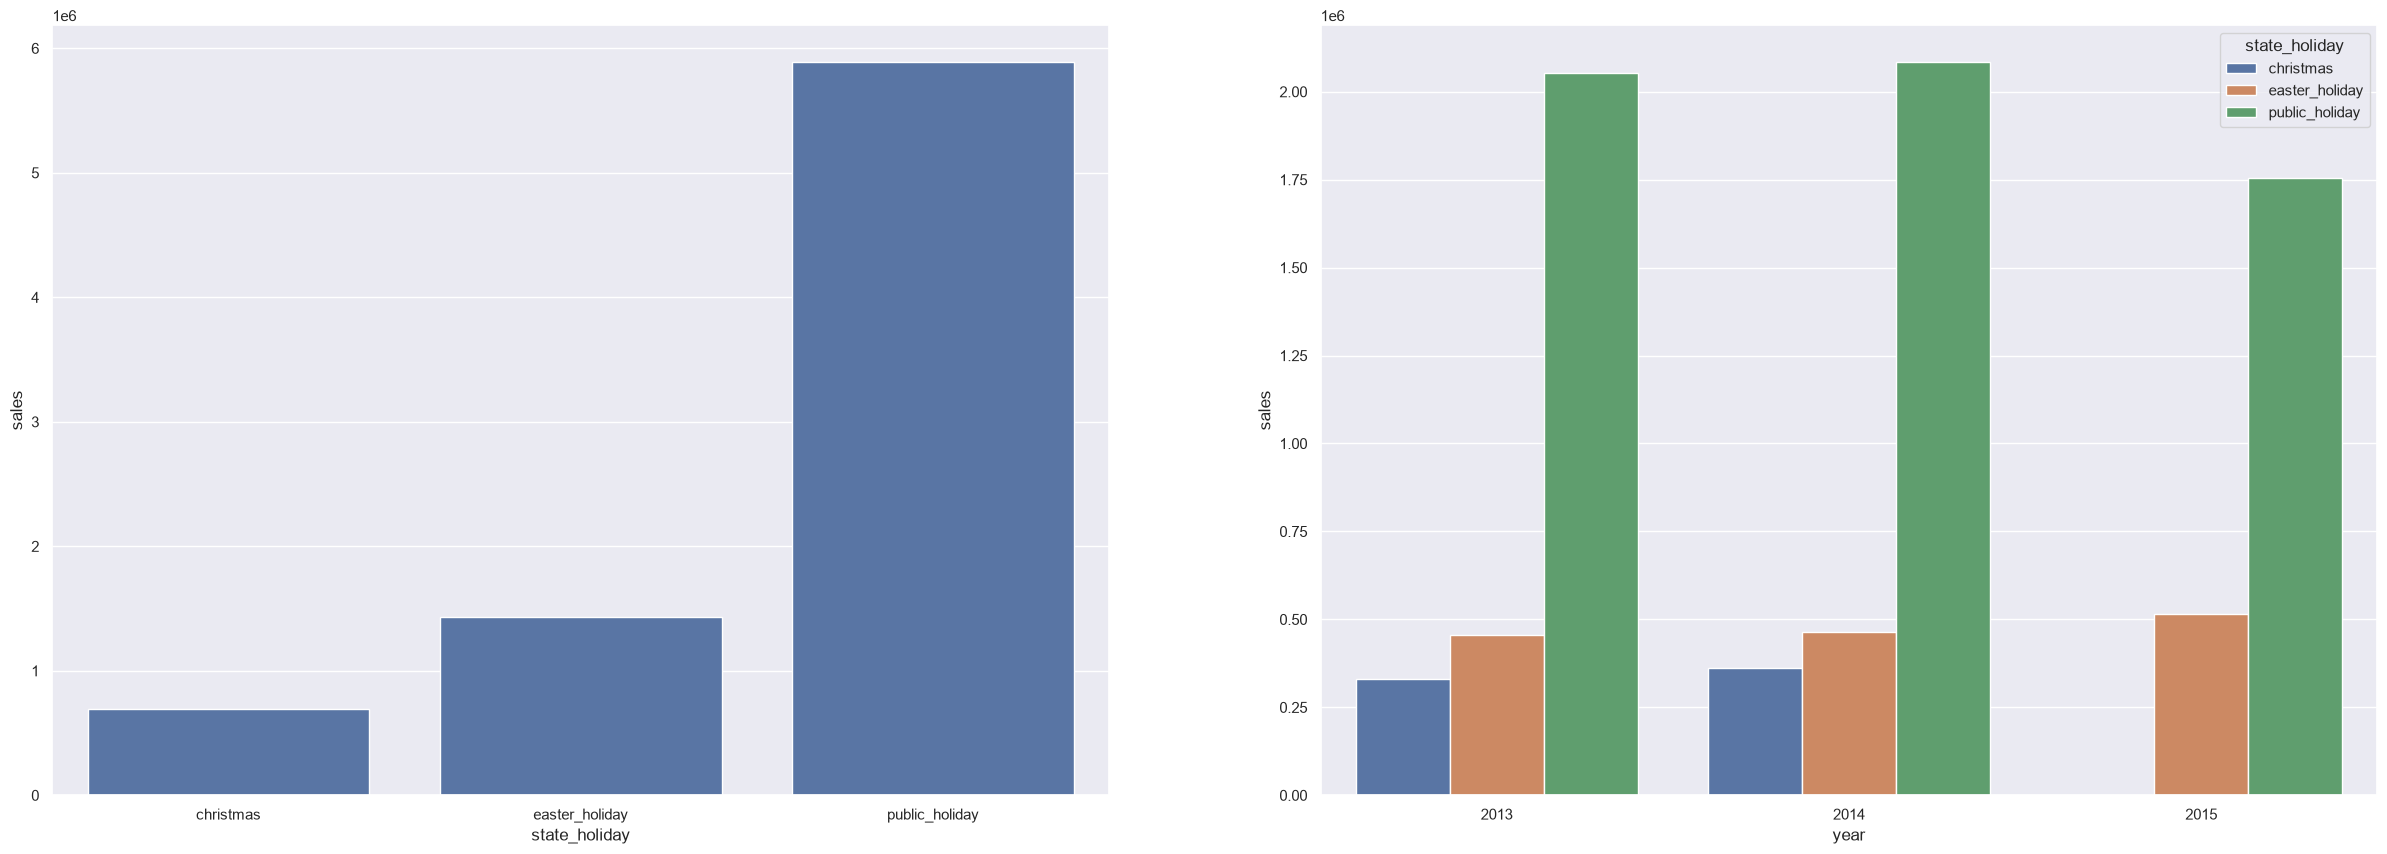

In [55]:
plt.figure(figsize=(30, 10))
aux14 =df4[df4['state_holiday']!= 'regular_day']

plt.subplot(1,2,1)
aux15 = aux14[['state_holiday','sales']].groupby(['state_holiday']).sum().reset_index()
sns.barplot(x= 'state_holiday', y='sales', data= aux15);

plt.subplot(1,2,2)
aux16= aux14[['year', 'state_holiday', 'sales']].groupby(['year','state_holiday']).sum().reset_index()
sns.barplot(x= 'year', y='sales',hue='state_holiday', data= aux16);

### **H8** Lojas ao longo dos anos vendem mais.

**FALSA** Lojas vendem menos ao longo dos anos.

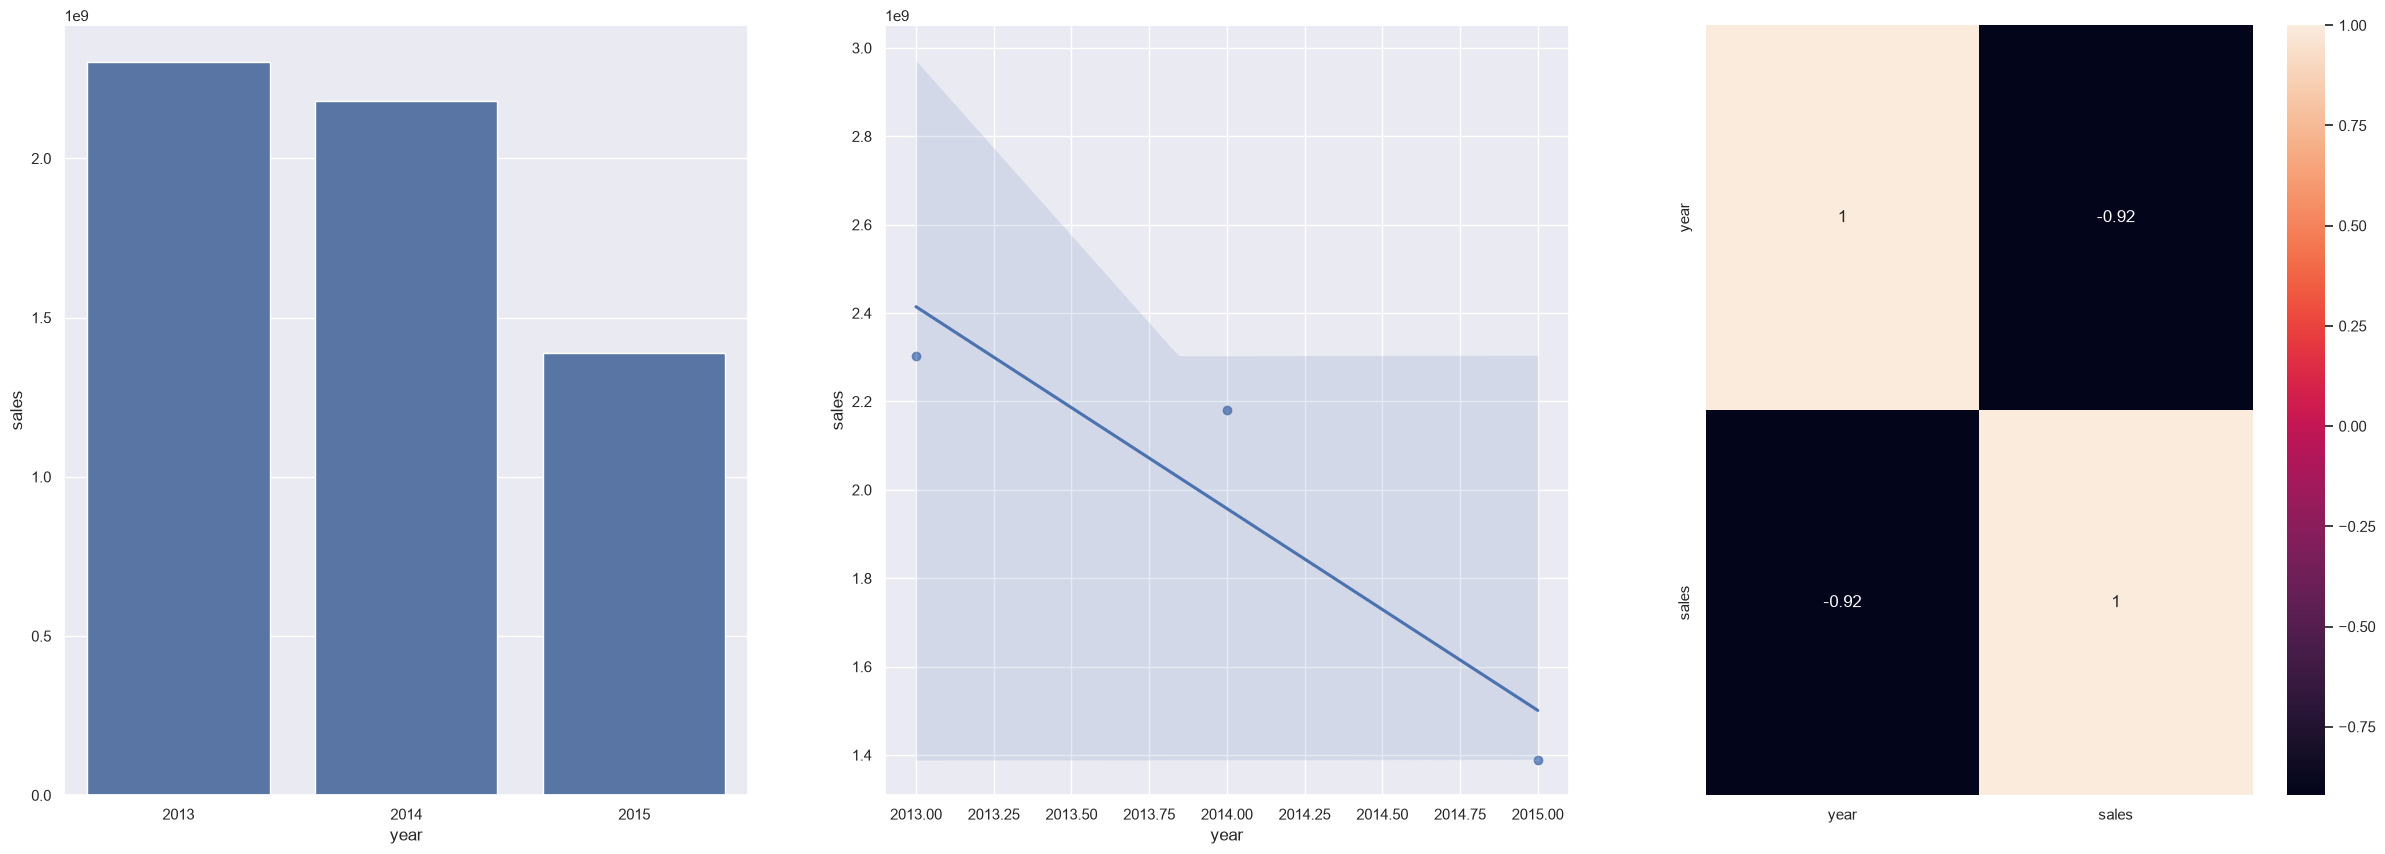

In [56]:
plt.figure(figsize=(30, 10))
aux17= df4[['year', 'sales']].groupby(['year']).sum().reset_index()

plt.subplot(1,3,1)
sns.barplot(x= 'year', y='sales', data= aux17);

plt.subplot(1,3,2)
sns.regplot(x= 'year', y='sales', data= aux17);

plt.subplot(1,3,3)
sns.heatmap(aux17.corr(method='pearson'),annot=True);

### **H9** Lojas vendem mais no segundo semestre do ano.

**FALSA** Lojas vendem menos no segundo semestre do ano.

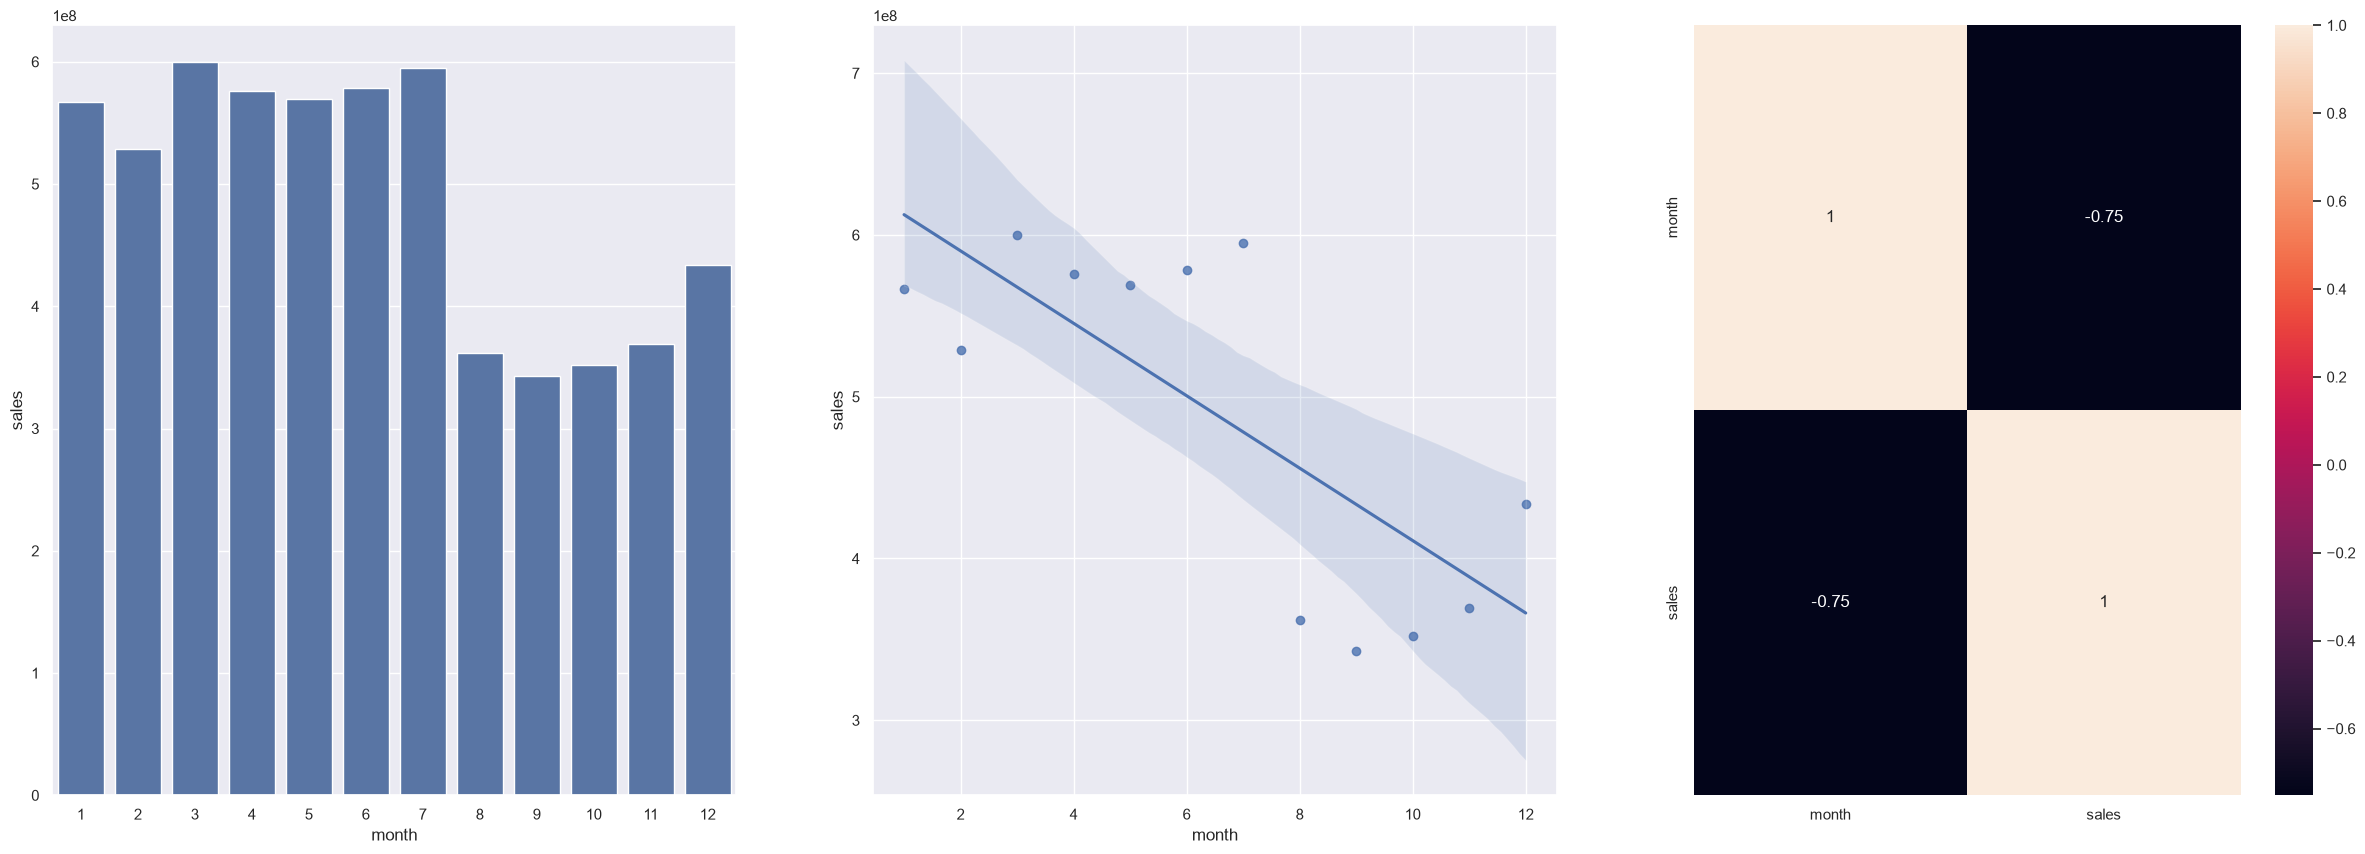

In [57]:
plt.figure(figsize=(30, 10))
aux18= df4[['month', 'sales']].groupby(['month']).sum().reset_index()

plt.subplot(1,3,1)
sns.barplot(x= 'month', y='sales', data= aux18);

plt.subplot(1,3,2)
sns.regplot(x= 'month', y='sales', data= aux18);

plt.subplot(1,3,3)
sns.heatmap(aux18.corr(method='pearson'),annot=True);

### **H10** Lojas vendem mais após o dia 10 de cada mês.

**VERDADEIRA** Lojas vendem mais  após o dia 10 de cada mês.

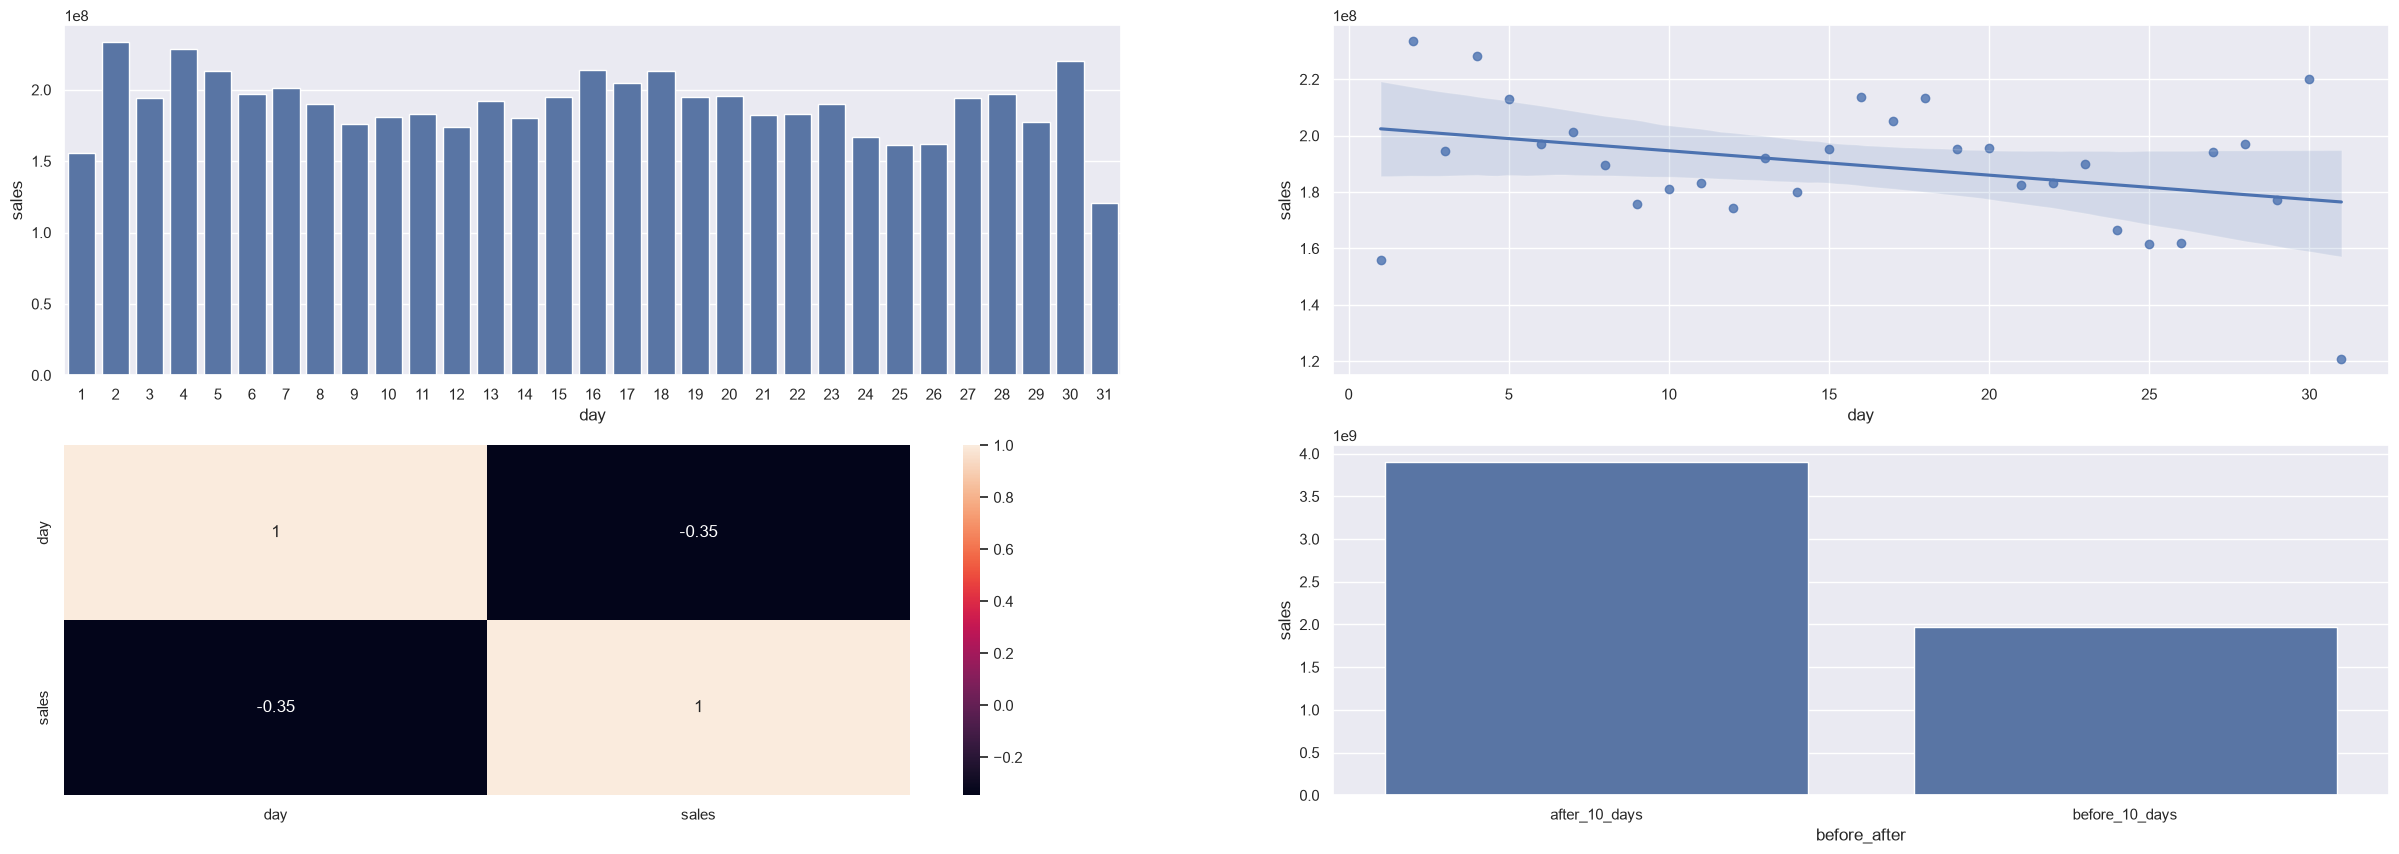

In [58]:
plt.figure(figsize=(30, 10))
aux19= df4[['day', 'sales']].groupby(['day']).sum().reset_index()

plt.subplot(2,2,1)
sns.barplot(x= 'day', y='sales', data= aux19);

plt.subplot(2,2,2)
sns.regplot(x= 'day', y='sales', data= aux19);

plt.subplot(2,2,3)
sns.heatmap(aux19.corr(method='pearson'),annot=True);

aux19['before_after']= aux19['day'].apply(lambda x: 'before_10_days' if x<=10 else 'after_10_days')
aux20= aux19[['before_after', 'sales']].groupby('before_after').sum().reset_index()
plt.subplot(2,2,4)
sns.barplot(x= 'before_after', y='sales', data= aux20);

### **H11** Lojas vendem menos aos finais de semana.

**VERDADEIRA** Lojas vendem menos aos finais de semana.

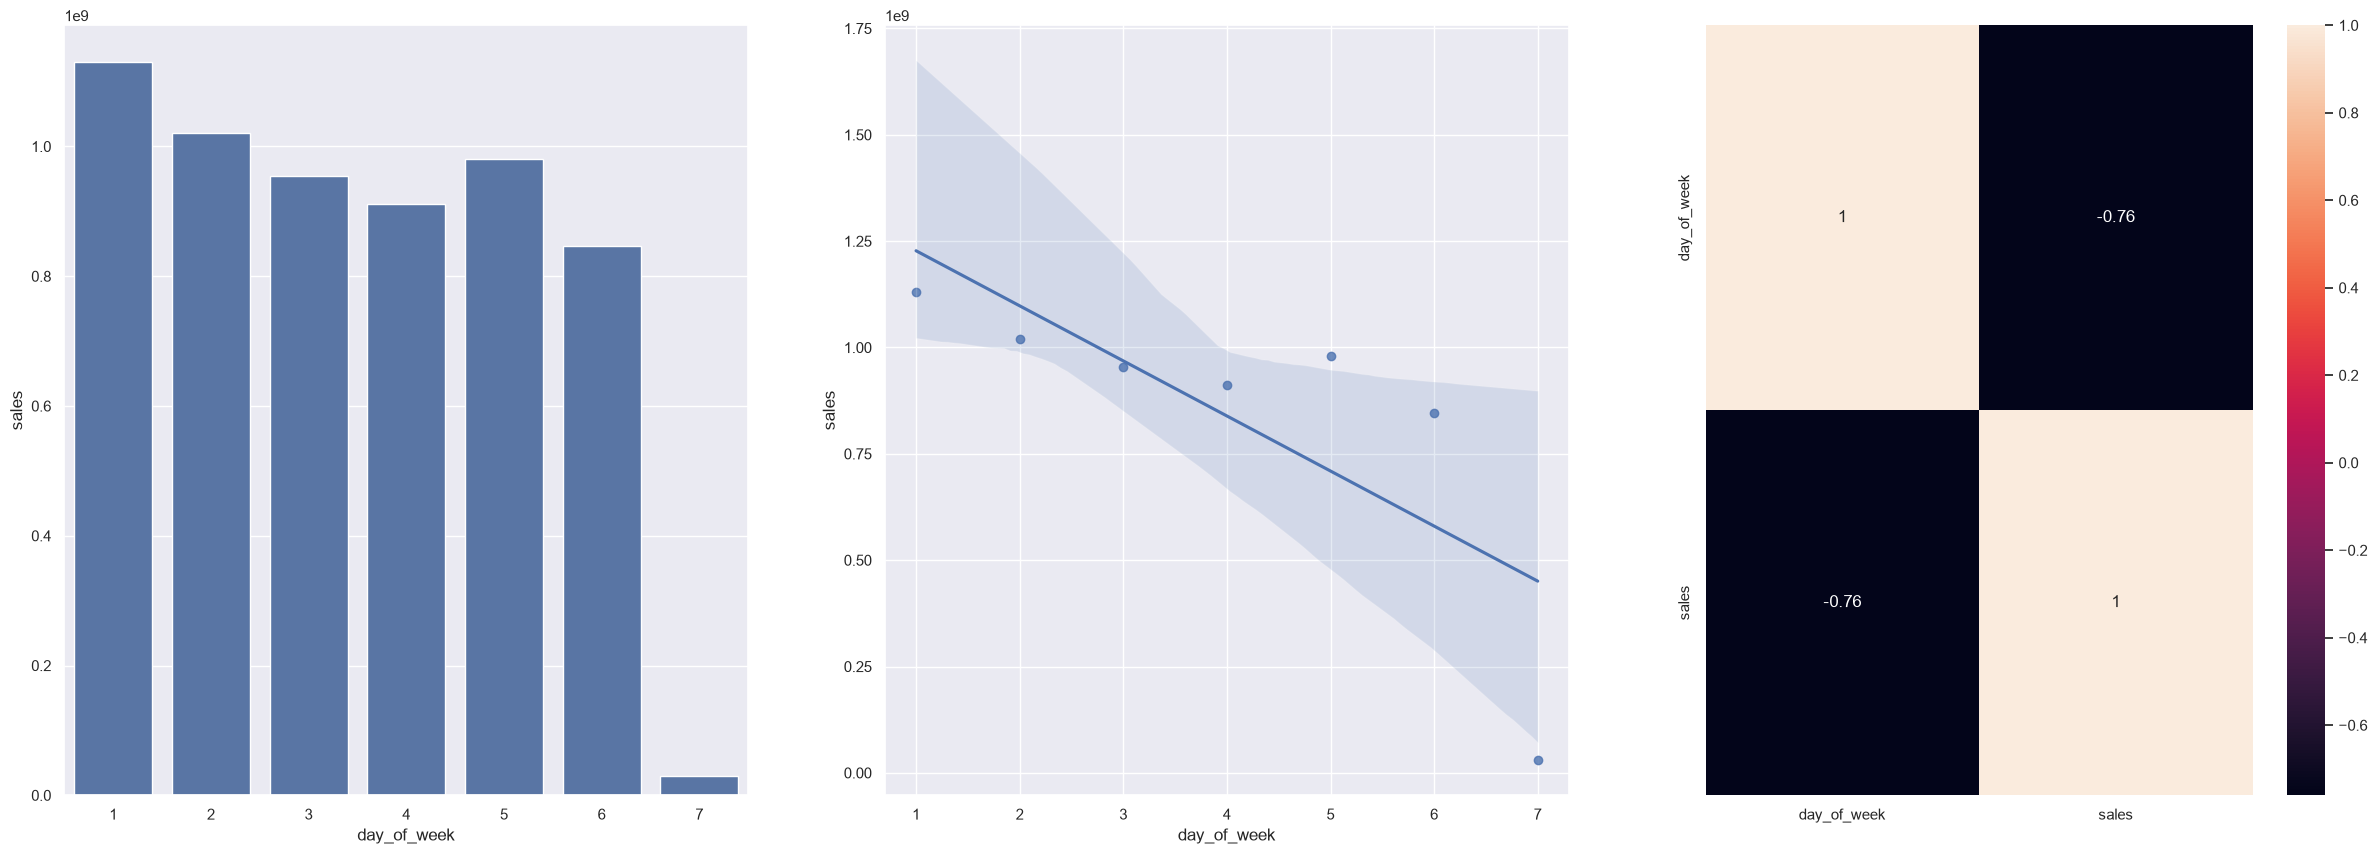

In [59]:
plt.figure(figsize=(30, 10))
aux21= df4[['day_of_week', 'sales']].groupby(['day_of_week']).sum().reset_index()

plt.subplot(1,3,1)
sns.barplot(x= 'day_of_week', y='sales', data= aux21);

plt.subplot(1,3,2)
sns.regplot(x= 'day_of_week', y='sales', data= aux21);

plt.subplot(1,3,3)
sns.heatmap(aux21.corr(method='pearson'),annot=True);

### **H12** Lojas vendem menos durante os feriados escolares.

**VERDADEIRA** Lojas vendem menos durante os feriados escolares, exceto para os meses de Julho e Agosto.

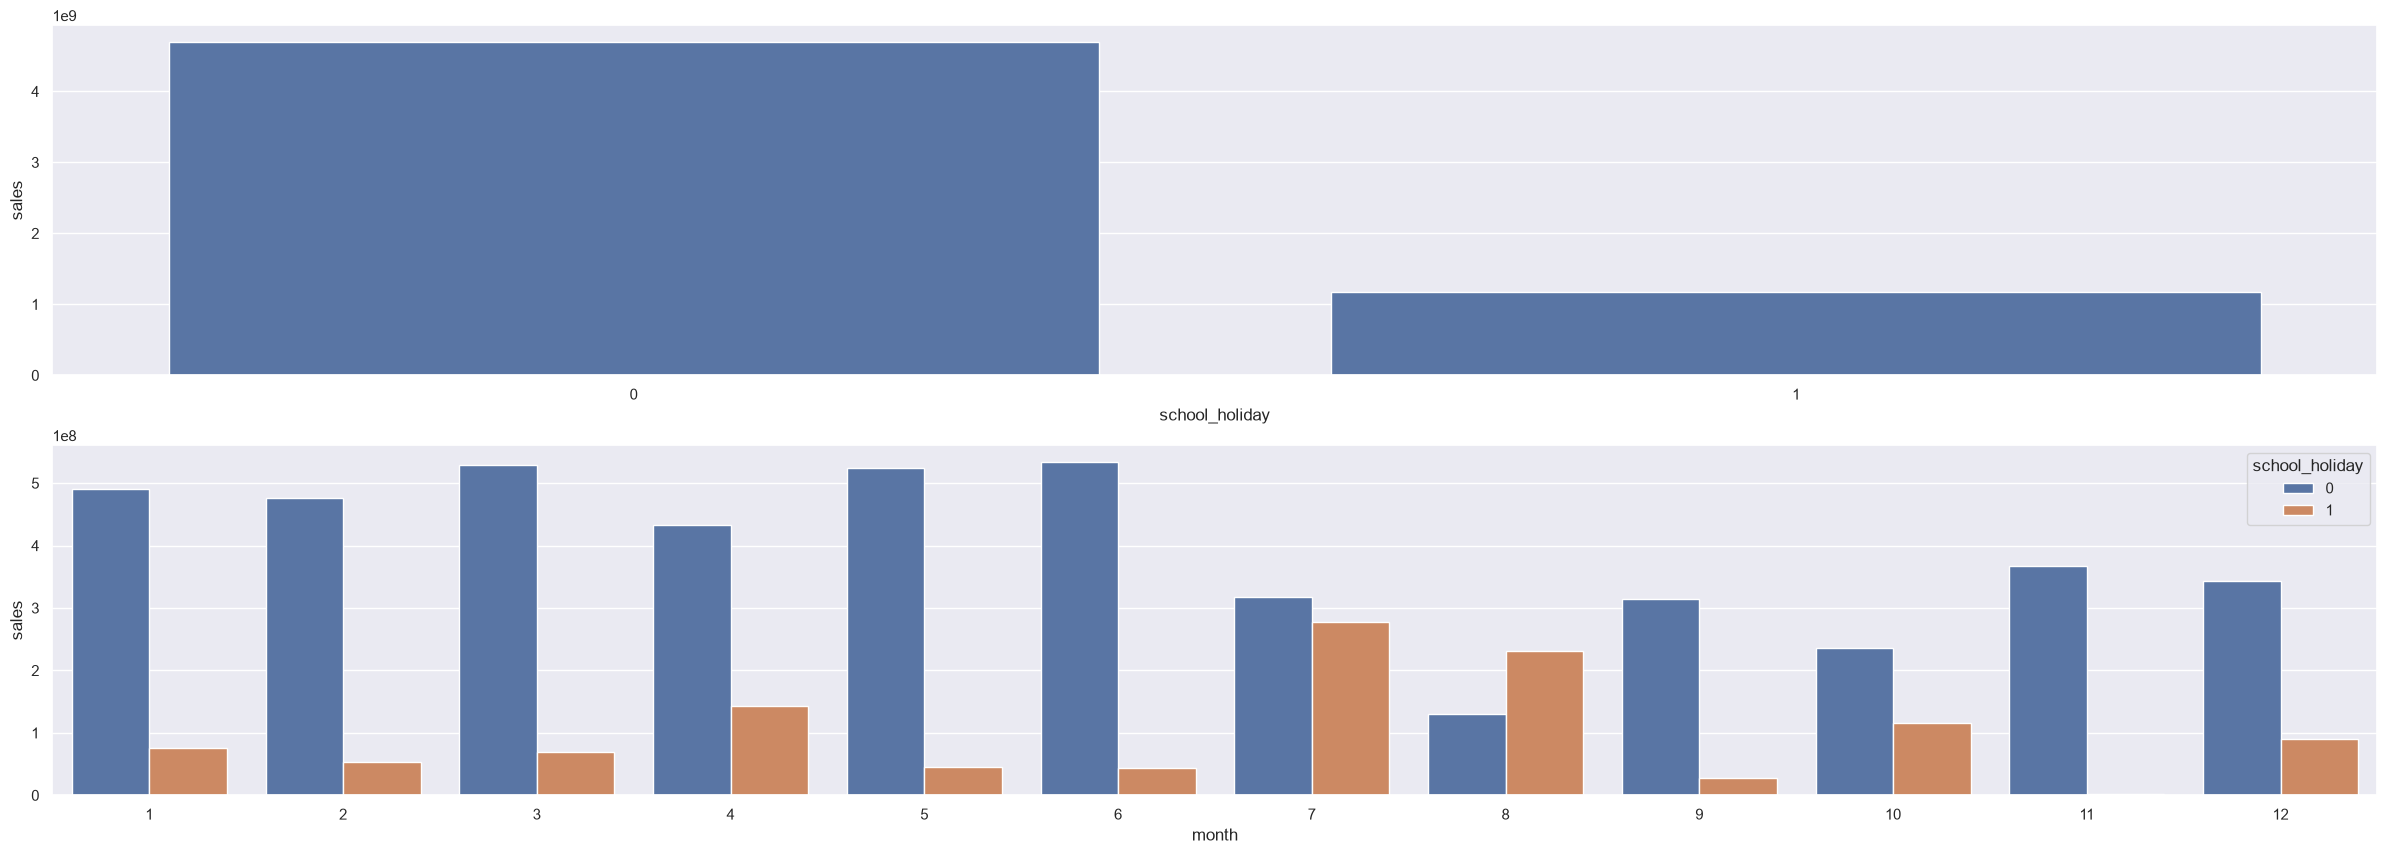

In [60]:
plt.figure(figsize=(30, 10))
plt.subplot(2,1,1)
aux22= df4[['school_holiday', 'sales']].groupby(['school_holiday']).sum().reset_index()
sns.barplot(x= 'school_holiday', y='sales', data= aux22);

plt.subplot(2,1,2)
aux23= df4[['month','school_holiday', 'sales']].groupby(['month','school_holiday']).sum().reset_index()
sns.barplot(x= 'month', y='sales',hue='school_holiday', data= aux23);

### 4.2.1 Resumo das Hipóteses

In [61]:
tab =[['Hipoteses', 'Conclusao', 'Relevancia'],
['H1', 'Falsa', 'Baixa'],
['H2', 'Falsa', 'Media'],
['H3', 'Falsa', 'Media'],
['H4', 'Falsa', 'Baixa'],
['H5', '-', '-'],
['H7', 'Falsa', 'Baixa'],
['H8', 'Falsa', 'Media'],
['H9', 'Falsa', 'Alta'],
['H10', 'Falsa', 'Alta'],
['H11', 'Verdadeira', 'Alta'],
['H12', 'Verdadeira', 'Alta'],
['H13', 'Verdadeira', 'Baixa'],
]
print( tabulate( tab, headers='firstrow' ) )

Hipoteses    Conclusao    Relevancia
-----------  -----------  ------------
H1           Falsa        Baixa
H2           Falsa        Media
H3           Falsa        Media
H4           Falsa        Baixa
H5           -            -
H7           Falsa        Baixa
H8           Falsa        Media
H9           Falsa        Alta
H10          Falsa        Alta
H11          Verdadeira   Alta
H12          Verdadeira   Alta
H13          Verdadeira   Baixa


## 4.3 Análise Multivariada

### 4.3.1 Numerical Attributes

In [62]:
# Atributos numéricos
num_attributes.head()

,store,day_of_week,sales,customers,open,promo,school_holiday,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo
0,1,5,5263,555,1,1,1,1270.0,9,2008,0,31,2015,0
1,2,5,6064,625,1,1,1,570.0,11,2007,1,13,2010,1
2,3,5,8314,821,1,1,1,14130.0,12,2006,1,14,2011,1
3,4,5,13995,1498,1,1,1,620.0,9,2009,0,31,2015,0
4,5,5,4822,559,1,1,1,29910.0,4,2015,0,31,2015,0


<Axes: >

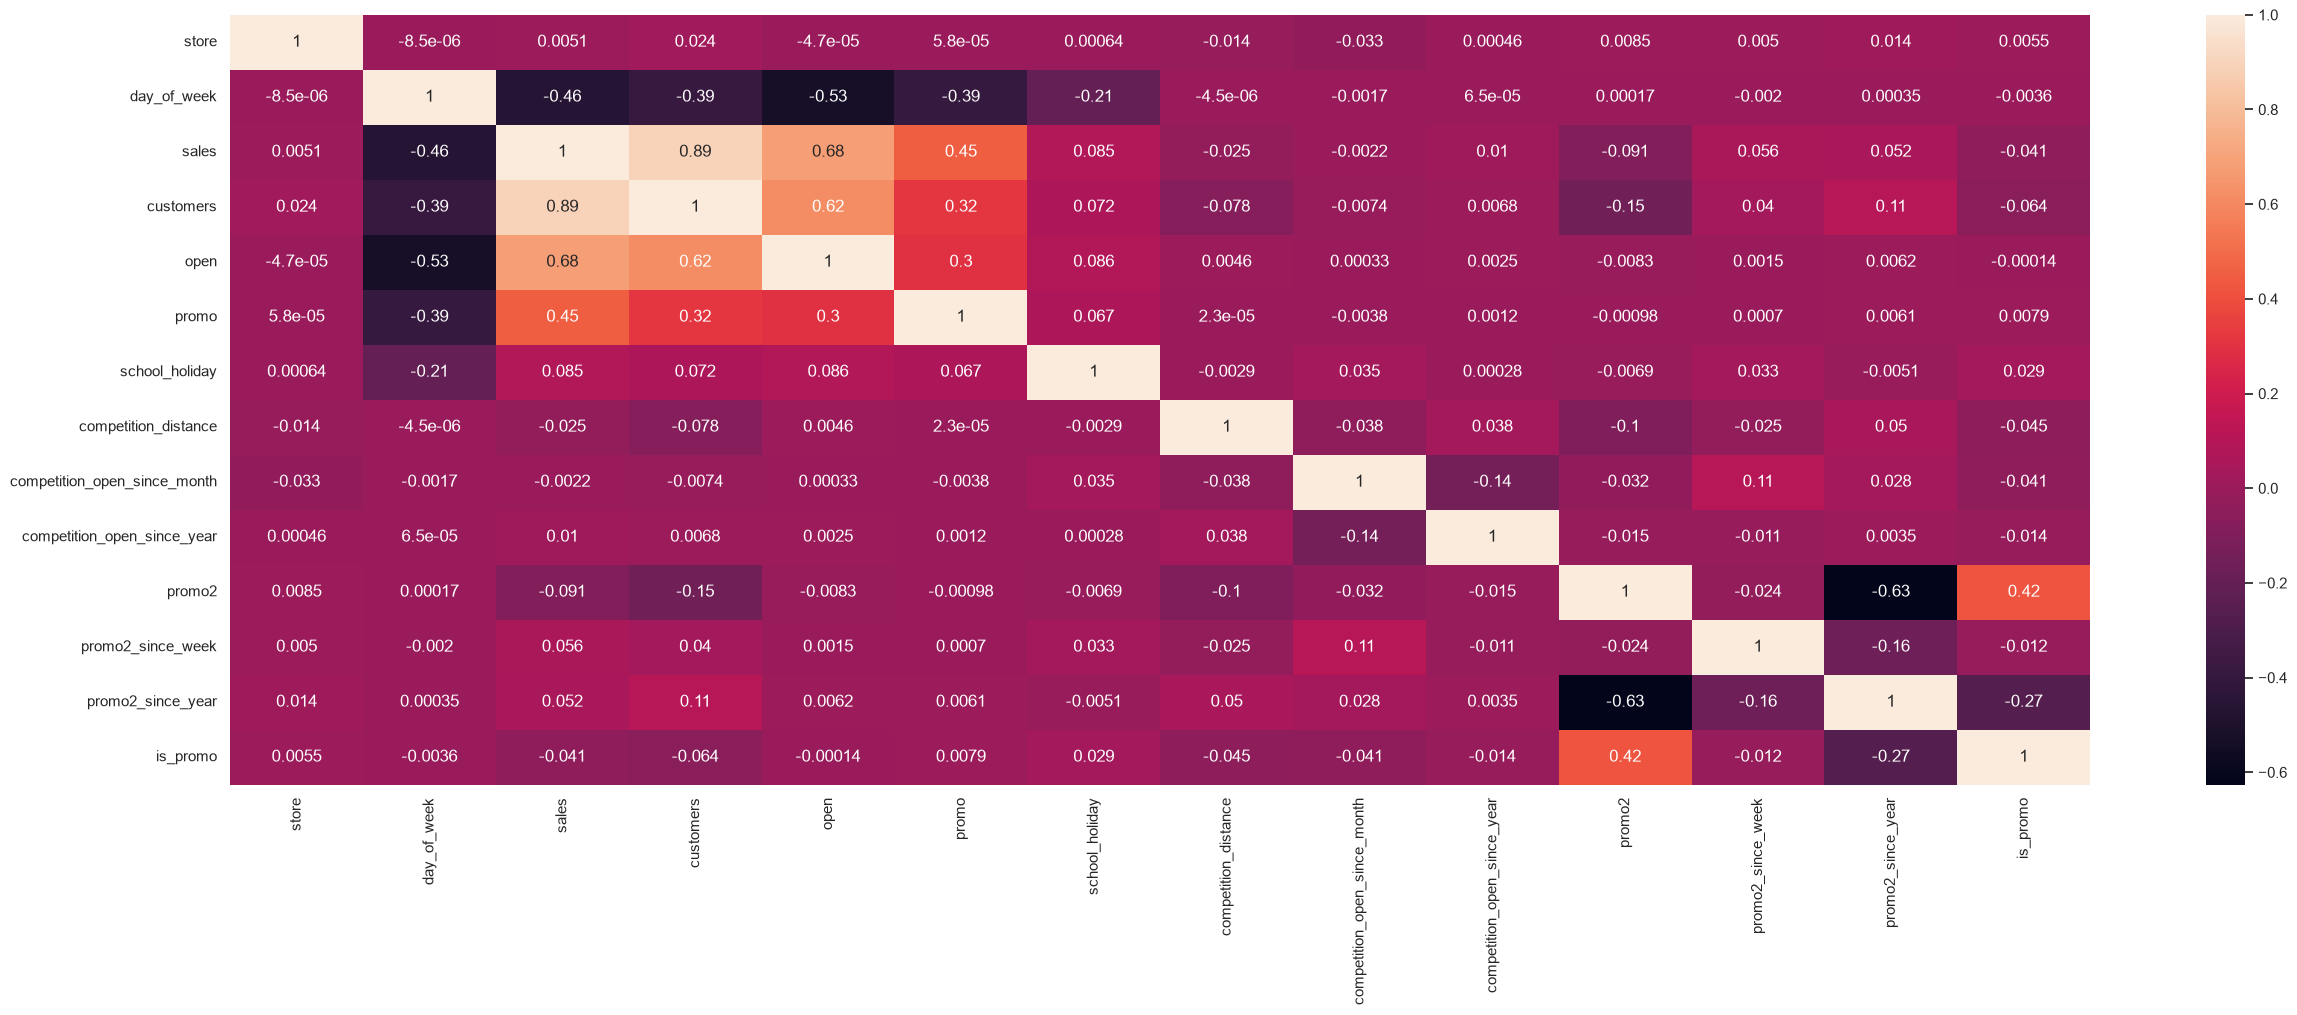

In [63]:
# Gráfico de Correlação
plt.figure(figsize=(30, 10))
correlation = num_attributes.corr(method='pearson')
sns.heatmap(correlation, annot=True)

### 4.3.2 Categorical Attributes

In [64]:
# Only categorical data
a = df4.select_dtypes(include='object')
a.head()

,state_holiday,store_type,assortment,year_week
0,regular_day,c,basic,2015-30
1,regular_day,a,basic,2015-30
2,regular_day,a,basic,2015-30
3,regular_day,c,extended,2015-30
4,regular_day,a,basic,2015-30


In [65]:
# cm = Matriz de confusão: todas as combinações entre as variáveis categóricas
cm = pd.crosstab(a['state_holiday'], a['store_type']).to_numpy()

#Chi² (Qui-quadrado ou Chi-Square) é um teste estatístico muito utilizado em análise exploratória de dados e Feature Selection para verificar se existe associação entre variáveis categóricas.
# Hipóteses: H₀ (nula): as variáveis são independentes , H₁ (alternativa): existe associação entre as variáveis.
chi2=ss.chi2_contingency(cm)
chi2

# Resultado 1 = Teste chi2
# Resultado 2 = p_value < 0.05, rejeitamos H₀, existe associação entre as variáveis ou p_value >= 0.05, não há evidências suficientes para afirmar associação.
# Resultado 3 = Grau de liberdade
# Resultado 4 = Tabela de frequência

Chi2ContingencyResult(statistic=np.float64(12792.159524019908), pvalue=np.float64(0.0), dof=9, expected_freq=array([[3.84324548e+01, 1.30843335e+00, 9.49942795e+00, 2.17596839e+01],
       [7.84888161e+01, 2.67215262e+00, 1.94002402e+01, 4.44387911e+01],
       [3.75663713e+02, 1.27894753e+01, 9.28535634e+01, 2.12693248e+02],
       [4.56549415e+05, 1.55432299e+04, 1.12846247e+05, 2.58489108e+05]]))

In [66]:
# Qui-quadrado
chi2=ss.chi2_contingency(cm)[0]
# n = soma de todos os valores
n=cm.sum()

# r=linhas e k=colunas

r,k = cm.shape

In [67]:
# Fórmula é o cálculo do Cramér's V, uma medida de associação entre duas variáveis categóricas baseada no teste Qui-Quadrado.
# Variáveis categóricas possuem apenas correlação positiva ou nenhuma correlação, sendo 0 menor correlação e 1 maior correlação.
vsqrt= np.sqrt((chi2/n)/(bt.min (k-1 , r-1)))
vsqrt

np.float64(0.07106457093267678)

In [68]:
# Criando um Dicionário Cramer V
def cramer_v (x,y):
    cm = pd.crosstab(x,y).to_numpy()
    n = cm.sum()
    r, k =cm.shape

    chi2 = ss.chi2_contingency(cm)[0]
    chi2corr = bt.max(0,chi2-(k-1)*(n-1)/(n-1))
    kcorr = k- (k-1)**2/(n-1)
    rcorr = r- (r-1)**2/(n-1)

    return np.sqrt((chi2corr/n)/(bt.min(kcorr-1, rcorr-1)))

In [69]:
cramer_v (a['state_holiday'],a['store_type'])

np.float64(0.07105636369510551)

In [70]:
# Only categorical data
a = df4.select_dtypes(include='object')

In [71]:
# Cramer V (cm): Matriz de confusão: todas as combinações entre as variáveis categóricas

a1 = cramer_v(a['state_holiday'], a['state_holiday'])
a2 = cramer_v(a['state_holiday'], a['store_type'])
a3 = cramer_v(a['state_holiday'], a['assortment'])

a4 = cramer_v(a['store_type'], a['state_holiday'])
a5 = cramer_v(a['store_type'], a['store_type'])
a6 = cramer_v(a['store_type'], a['assortment'])

a7 = cramer_v(a['assortment'], a['state_holiday'])
a8 = cramer_v(a['assortment'], a['store_type'])
a9 = cramer_v(a['assortment'], a['assortment'])

# Dataset final
d = pd.DataFrame({'state_holiday': [a1,a2,a3],
    'store_type': [a4,a5,a6],
    'assortment': [a7,a8,a9]})

d = d.set_index(d.columns)
d

,state_holiday,store_type,assortment
state_holiday,1.000001,0.071056,0.067532
store_type,0.071056,1.000001,0.538455
assortment,0.067537,0.538456,1.000001


<Axes: >

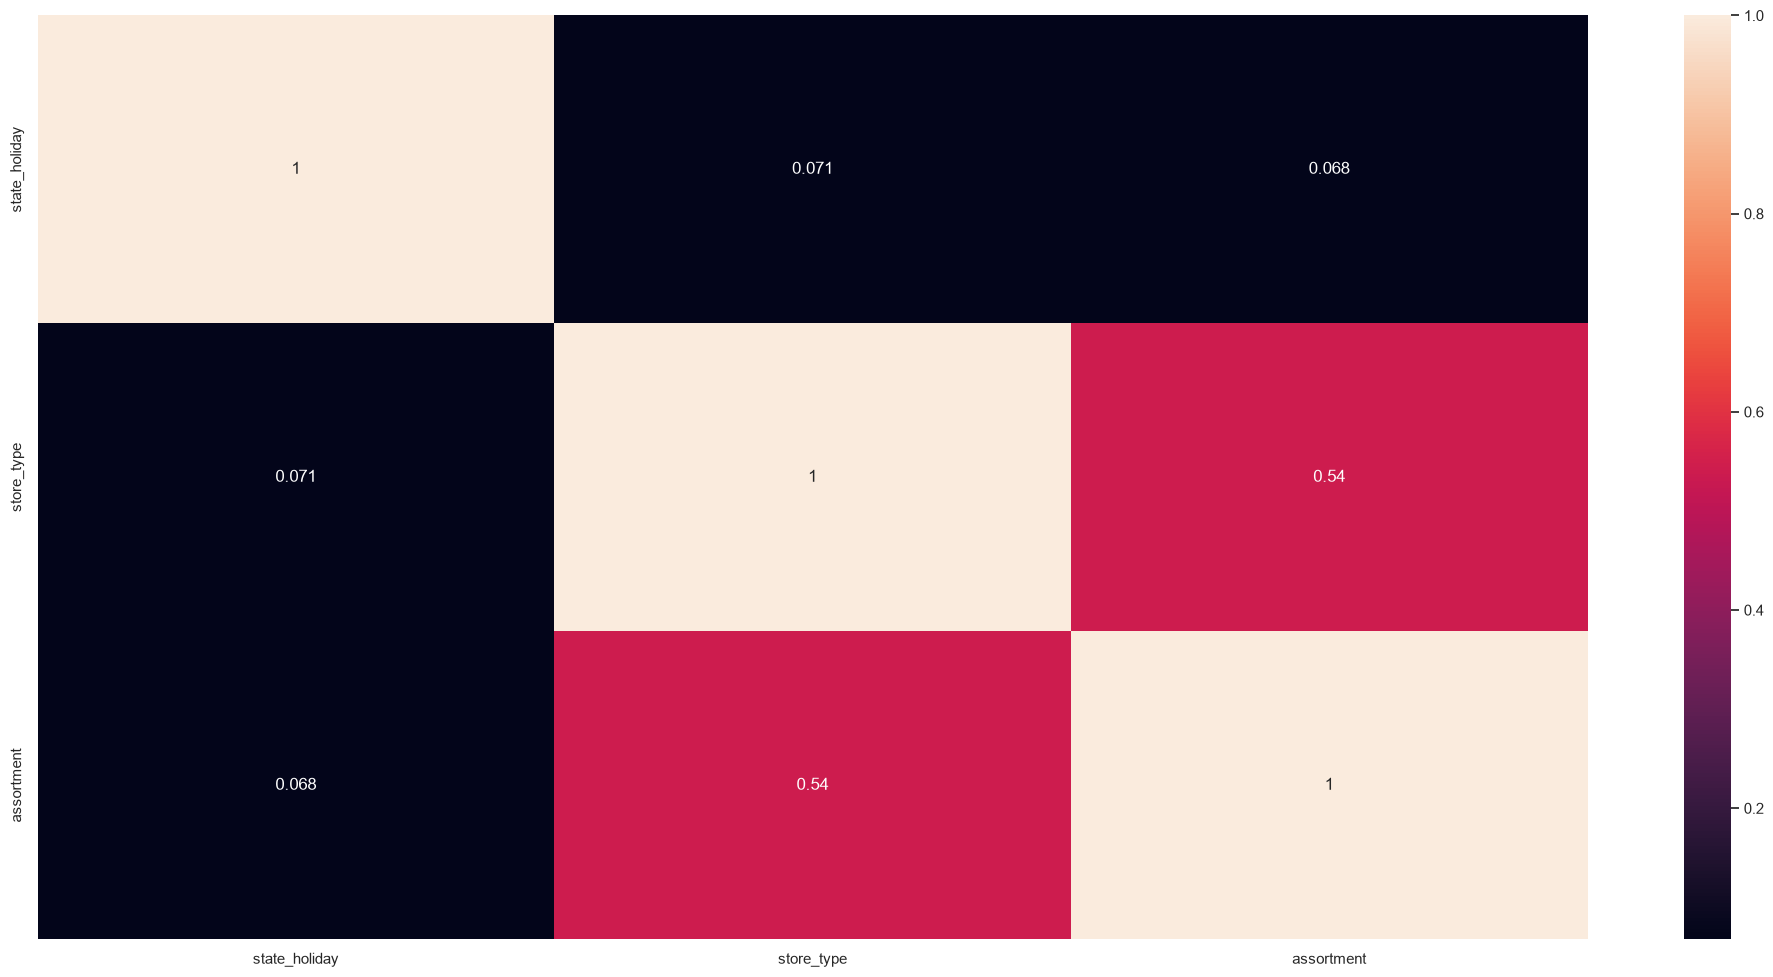

In [72]:
# Gráfico Cramer V (cm)
sns.heatmap(d, annot=True)

In [73]:
df4.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
is_promo                        0
year                            0
month                           0
day                             0
week_year                       0
year_week                       0
competition_since               0
competition_time_month          0
promo_since                     0
promo_time_week                 0
dtype: int64

# 5.0 Data Preparation

### Distribuição normal: onde a maioria dos valores fica próxima da média e a frequência diminui conforme nos afastamos dela.
    1) Simétrica
    O lado esquerdo é o espelho do lado direito.
    Média = Mediana = Moda.

    2) Concentração dos dados
    A maioria dos valores fica próxima da média.
    Valores muito altos ou muito baixos são raros.

    3) Definida por dois parâmetros
    Média: centro da distribuição.
    Desvio padrão: dispersão dos dados.

### Normalização: reescala o centro para 0 com desvio padrão = 1. Para variáveis com distribuição normal.
    Xnew = (X - med)/desv. padrão

### Rescaling: para variáveis que não possuem umadistribuição normal (não Gaussianas). Para variáveis sem distribuição normal.
    Min-Max-Scaler:
    Xnew = (X - média)/(Xmax - Xmin)

    1) Adequa o resultado ao range, mantendo a natureza da distribuição.
    2) Sensível a outliers. Para minimizar os efeitos dos outliers, utiliza-se o Robust Scaler (boxplot).
    IQR (interquartile range) = Q3-Q1
    Xnew = (X - Q1)/(Q3 - Q1)

### Transformação:
    1) Encoding: transforma variaveis categóricas em numéricas.
    2) Natureza cíclica

### 5.1 Normalização

#### A distribuição das variáveis encontra-se na **análise univariada**.
#### Como não há variável com distribuuição normal, não iremos normalizar nenhuma das variáveis.

In [74]:
df5= df4.copy()

## 5.2 Rescaling

In [75]:
# Seleção variáveis numéricas
df5.head().select_dtypes(include=['int64', 'float64'])

,store,day_of_week,sales,promo,school_holiday,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,competition_time_month,promo_time_week
0,1,5,5263,1,1,1270.0,9,2008,0,31,2015,0,84,0
1,2,5,6064,1,1,570.0,11,2007,1,13,2010,1,94,279
2,3,5,8314,1,1,14130.0,12,2006,1,14,2011,1,105,226
3,4,5,13995,1,1,620.0,9,2009,0,31,2015,0,71,0
4,5,5,4822,1,1,29910.0,4,2015,0,31,2015,0,4,0


<Axes: ylabel='competition_distance'>

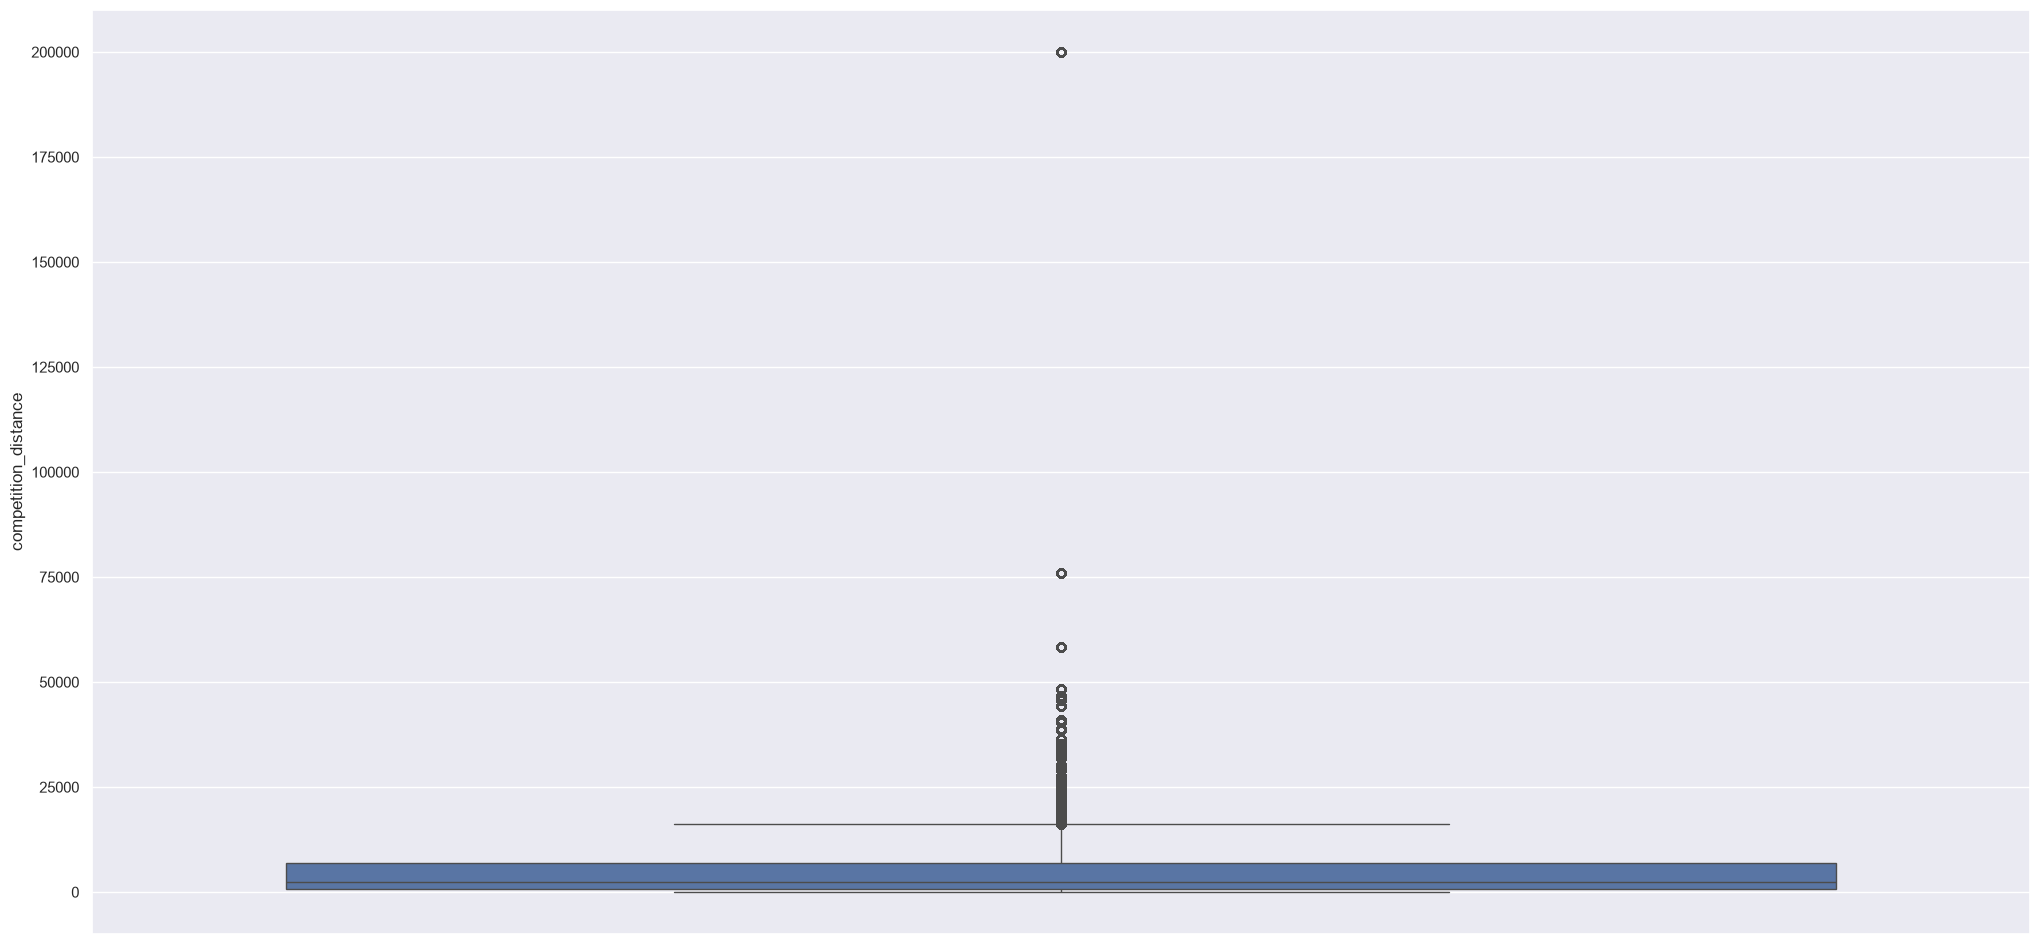

In [76]:
# verificação de outliers
sns.boxplot(df5['competition_distance'])

In [77]:
# Para variáveis com muitos outliers
rs = RobustScaler()

# Para variáveis com poucos outliers
mms = MinMaxScaler()

# VARIÁVEIS
# competition_distance
df5['competition_distance'] = rs.fit_transform(df5[['competition_distance']].values)

# year
df5['year'] = mms.fit_transform(df5[['year']].values)

# competition_time_month
df5['competition_time_month'] = rs.fit_transform(df5[['competition_time_month']].values)

# promo_time_week
df5['promo_time_week'] = mms.fit_transform(df5[['promo_time_week']].values)

<Axes: xlabel='competition_distance', ylabel='Density'>

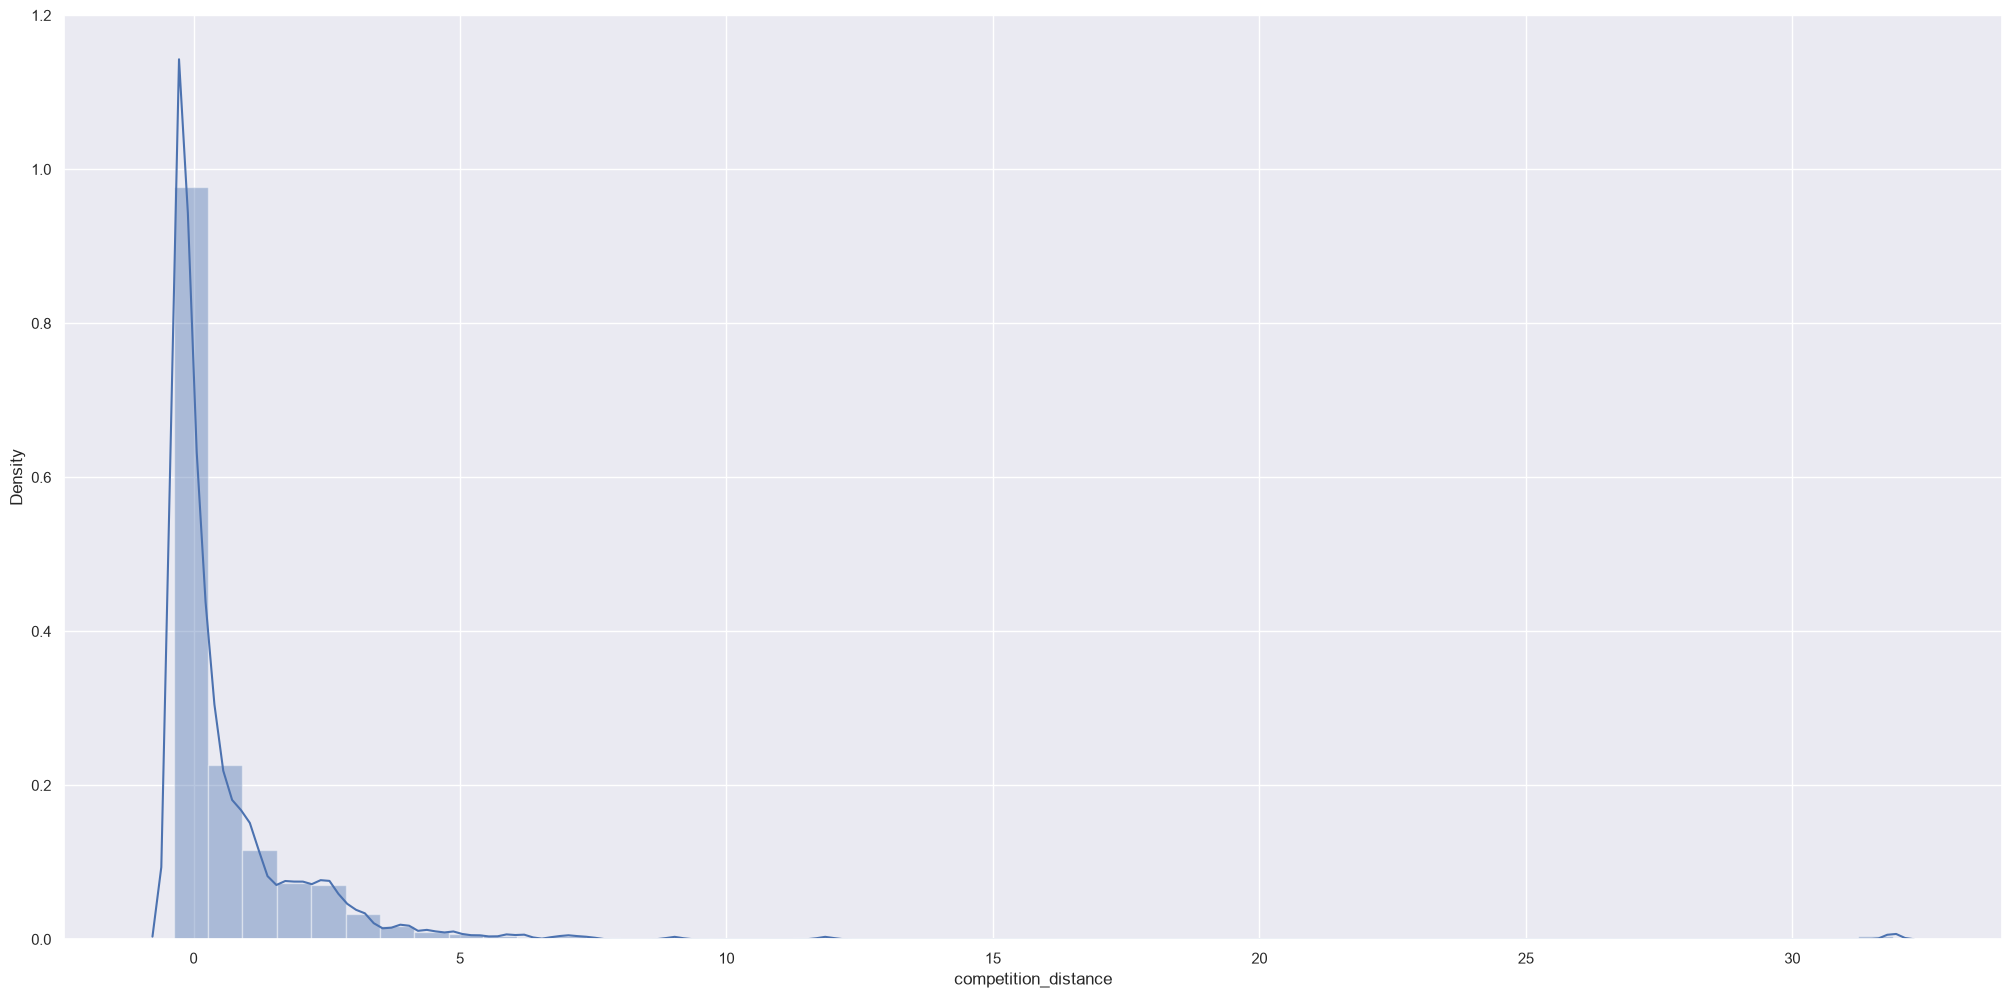

In [78]:
# Nova redistribuição na escala
sns.distplot(df5['competition_distance'])

In [79]:
df5.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
is_promo                        0
year                            0
month                           0
day                             0
week_year                       0
year_week                       0
competition_since               0
competition_time_month          0
promo_since                     0
promo_time_week                 0
dtype: int64

## 5.3 Transformação

### 5.3.1 Transformação de variáveis categóricas em variáveis numéricas.

    1) One hot Encoding: categorização binária (0,1) para cada tipo de resposta, sendo 1 apenas na label da variável. Cada categoria vira uma coluna.
    2) Label Encoding: categorização em número aleatório cada tipo de resposta.
    3) Ordinal Encoding: categorização ordinal de acordo com a graduaçãoda categoria;
    4) Target Encoding: média da variável resposta (frequência/soma da coluna). Utilizado quando há uma grande variação de variáveis respostas;
    5) Frequency Encoding: número absoluto da frequência da variável resposta.
    6) Embedding Encoding: transforma categorias em vetores numéricos densos de baixa dimensão, permitindo que o modelo aprenda relações entre as categorias através de redes neurais. Muito utilizado em NLP (Natural Language Processing) ou Processamento de Linguagem Natural é a área da Inteligência Artificial que permite que computadores compreendam, interpretem e gerem linguagem humana.

In [80]:
# Verificar tabela de variáveis categóricas
df5.head(5).select_dtypes(include=['str','bool'])

,state_holiday,store_type,assortment,year_week
0,regular_day,c,basic,2015-30
1,regular_day,a,basic,2015-30
2,regular_day,a,basic,2015-30
3,regular_day,c,extended,2015-30
4,regular_day,a,basic,2015-30


In [81]:
# Encoding das variáveis categóricas

# state_holiday - One Hot Encoding
df5 = pd.get_dummies(df5, prefix=['state_holiday'],columns=['state_holiday'])

# store_type - Label Encoding
le = LabelEncoder()
df5['store_type']=le.fit_transform(df5['store_type'])

# assortment - Ordinal Encoding
df5['assortment']= df5['assortment'].map({
    'basic':1,
    'extra':2,
    'extended':3
    })


In [82]:
df5.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
promo                           0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
is_promo                        0
year                            0
month                           0
day                             0
week_year                       0
year_week                       0
competition_since               0
competition_time_month          0
promo_since                     0
promo_time_week                 0
state_holiday_christmas         0
state_holiday_easter_holiday    0
state_holiday_public_holiday    0
state_holiday_regular_day       0
dtype: int64

In [83]:
# Verificar tabela de variáveis categóricas após encoding
df5.head()

,store,day_of_week,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,month,day,week_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week,state_holiday_christmas,state_holiday_easter_holiday,state_holiday_public_holiday,state_holiday_regular_day
0,1,5,2015-07-31,5263,1,1,2,1,-0.170968,9,2008,0,31,2015,0,1.0,7,31,31,2015-30,2008-09-01,0.918919,2015-07-27,0.287016,False,False,False,True
1,2,5,2015-07-31,6064,1,1,0,1,-0.283871,11,2007,1,13,2010,1,1.0,7,31,31,2015-30,2007-11-01,1.054054,2010-03-22,0.922551,False,False,False,True
2,3,5,2015-07-31,8314,1,1,0,1,1.903226,12,2006,1,14,2011,1,1.0,7,31,31,2015-30,2006-12-01,1.202703,2011-03-28,0.801822,False,False,False,True
3,4,5,2015-07-31,13995,1,1,2,3,-0.275806,9,2009,0,31,2015,0,1.0,7,31,31,2015-30,2009-09-01,0.743243,2015-07-27,0.287016,False,False,False,True
4,5,5,2015-07-31,4822,1,1,0,1,4.448387,4,2015,0,31,2015,0,1.0,7,31,31,2015-30,2015-04-01,-0.162162,2015-07-27,0.287016,False,False,False,True


### 5.3.2 Response Variable Transformation
    Tipos de transformações:
        1) Grandeza: variável resposta mais próximo de uma normal para que haja maior acurácia da premissa do algoritmo.
            - Logarithm tranformation
            - Box-Cox transformation
            - Cube-Root transformation
            - Square-Root transformation
            - Sine and Cosine transformation

        2) Natureza: manter o comportamento real do conjunto de dados.

#### 5.3.2.1 Response Variable Transformation - Grandeza

In [84]:
# Logarithm transformation
df5['sales']= np.log1p(df5['sales'])

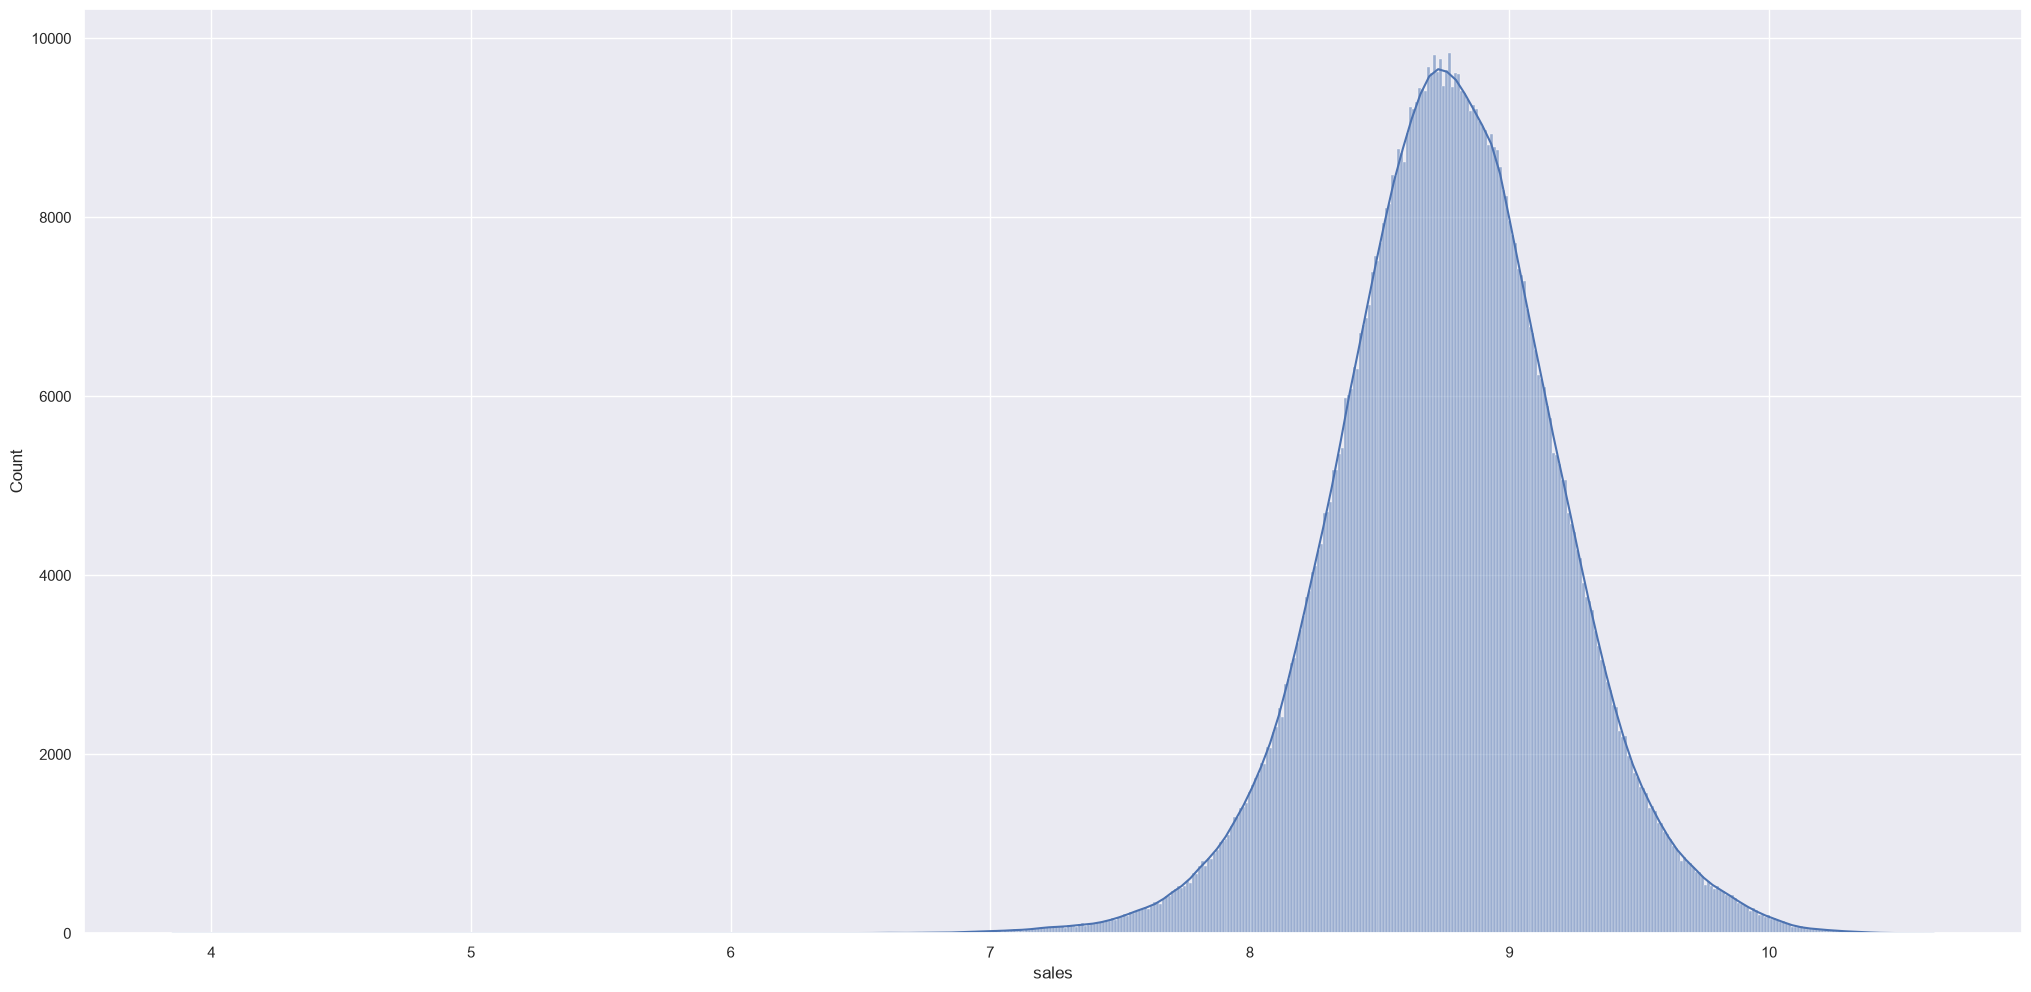

In [85]:
sns.histplot(df5['sales'], kde=True)
plt.show()

#### 5.3.2.2 Response Variable Transformation - Natureza

In [86]:
df5.head()

,store,day_of_week,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,month,day,week_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week,state_holiday_christmas,state_holiday_easter_holiday,state_holiday_public_holiday,state_holiday_regular_day
0,1,5,2015-07-31,8.568646,1,1,2,1,-0.170968,9,2008,0,31,2015,0,1.0,7,31,31,2015-30,2008-09-01,0.918919,2015-07-27,0.287016,False,False,False,True
1,2,5,2015-07-31,8.710290,1,1,0,1,-0.283871,11,2007,1,13,2010,1,1.0,7,31,31,2015-30,2007-11-01,1.054054,2010-03-22,0.922551,False,False,False,True
2,3,5,2015-07-31,9.025816,1,1,0,1,1.903226,12,2006,1,14,2011,1,1.0,7,31,31,2015-30,2006-12-01,1.202703,2011-03-28,0.801822,False,False,False,True
3,4,5,2015-07-31,9.546527,1,1,2,3,-0.275806,9,2009,0,31,2015,0,1.0,7,31,31,2015-30,2009-09-01,0.743243,2015-07-27,0.287016,False,False,False,True
4,5,5,2015-07-31,8.481151,1,1,0,1,4.448387,4,2015,0,31,2015,0,1.0,7,31,31,2015-30,2015-04-01,-0.162162,2015-07-27,0.287016,False,False,False,True


In [87]:
# day_of_week
df5['day_of_week_sin'] = df5['day_of_week'].apply(lambda x: np.sin(x* (2* np.pi/7)))
df5['day_of_week_cos'] = df5['day_of_week'].apply(lambda x: np.cos(x* (2* np.pi/7)))

# month
df5['month_sin'] = df5['month'].apply(lambda x: np.sin(x* (2* np.pi/12)))
df5['month_cos'] = df5['month'].apply(lambda x: np.cos(x* (2* np.pi/12)))

# day
df5['day_sin'] = df5['day'].apply(lambda x: np.sin(x* (2* np.pi/30)))
df5['day_cos'] = df5['day'].apply(lambda x: np.cos(x* (2* np.pi/30)))

# week_of_year
df5['week_of_year_sin'] = df5['week_year'].apply(lambda x: np.sin(x* (2* np.pi/52)))
df5['week_of_year_cos'] = df5['week_year'].apply(lambda x: np.cos(x* (2* np.pi/52)))

In [88]:
df5.head()

,store,day_of_week,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,month,day,week_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week,state_holiday_christmas,state_holiday_easter_holiday,state_holiday_public_holiday,state_holiday_regular_day,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_sin,day_cos,week_of_year_sin,week_of_year_cos
0,1,5,2015-07-31,8.568646,1,1,2,1,-0.170968,9,2008,0,31,2015,0,1.0,7,31,31,2015-30,2008-09-01,0.918919,2015-07-27,0.287016,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
1,2,5,2015-07-31,8.710290,1,1,0,1,-0.283871,11,2007,1,13,2010,1,1.0,7,31,31,2015-30,2007-11-01,1.054054,2010-03-22,0.922551,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
2,3,5,2015-07-31,9.025816,1,1,0,1,1.903226,12,2006,1,14,2011,1,1.0,7,31,31,2015-30,2006-12-01,1.202703,2011-03-28,0.801822,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
3,4,5,2015-07-31,9.546527,1,1,2,3,-0.275806,9,2009,0,31,2015,0,1.0,7,31,31,2015-30,2009-09-01,0.743243,2015-07-27,0.287016,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
4,5,5,2015-07-31,8.481151,1,1,0,1,4.448387,4,2015,0,31,2015,0,1.0,7,31,31,2015-30,2015-04-01,-0.162162,2015-07-27,0.287016,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984


In [89]:
df5.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
promo                           0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
is_promo                        0
year                            0
month                           0
day                             0
week_year                       0
year_week                       0
competition_since               0
competition_time_month          0
promo_since                     0
promo_time_week                 0
state_holiday_christmas         0
state_holiday_easter_holiday    0
state_holiday_public_holiday    0
state_holiday_regular_day       0
day_of_week_sin                 0
day_of_week_co

# 6.0 Seleção de Variáveis

### Métodos para cálculo de correlação:
    1) Pearson: var x numérica, var y numérica;
    2) Linear Discriminant Analysis (LDA):  var x numérica, var y categórica;
    3) Anova: var x categórica, var y numérica;
    4) Cramer's V ou Chi-Square: var x categórica, var y categórica;

    >> Random Forest: índice Gini impurity - escolher divisões que deixem os grupos o mais homogêneos possível, ou seja, contendo observações predominantemente de uma única classe.
    
    >> Lasso Regression: Encolhe e elimina coeficientes.

    >> Ridge Regression: Encolhe coeficientes.

    >> Elastic Net: Mistura os dois comportamentos.


    - Random Forest (Gini)
        A escolha da variável se dá pela divisão homogênea entre si.

    - Algoritmos de Regressão (Lasso Regression, Ridge Regression e Elastic Net)
        São técnicas de regularização usadas para melhorar a capacidade de generalização de modelos de regressão, reduzindo o risco de overfitting. Calcula os pesos das variáveis, indicando a relevância da variável para o modelo. É muito importante padronizar as variáveis (StandardScaler) antes de aplicar Lasso ou Ridge, porque a penalização é sensível à escala das features. Elastic Net, combina Lasso e Ridge.

    - Algoritmo Boruta
        Seleção por Subset: testa cada feature ou variável e calcula a performance em porcentagem da variável resposta. Caso haja aumento da acurácia, significa que a variável é relevante e permanece, caso contrário é irrelevante e por isso retirado do modelo.

    p-value: determina se uma variável é relevante para a variável resposta. O p-value representa a probabilidade de observarmos um resultado tão extremo quanto o obtido (ou mais extremo), assumindo que a hipótese nula, quando maior que o nível de significância (threshold), seja verdadeira.

    Como o Boruta funciona:
        Em cada iteração ele 
        1) Cria cópias aleatórias das variáveis (shadow features).
        2) Treina uma Random Forest.
        3) Compara a importância de cada variável real com a melhor shadow feature.
        4) Decide: Confirmar, rejeitar ou manter como Tentative. Nas primeiras iterações quase tudo fica como Tentative.

## 6.1 Split Dataframe into Training and Test Dataset

In [90]:
df6= df5.copy()
df6.head(5)

,store,day_of_week,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,month,day,week_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week,state_holiday_christmas,state_holiday_easter_holiday,state_holiday_public_holiday,state_holiday_regular_day,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_sin,day_cos,week_of_year_sin,week_of_year_cos
0,1,5,2015-07-31,8.568646,1,1,2,1,-0.170968,9,2008,0,31,2015,0,1.0,7,31,31,2015-30,2008-09-01,0.918919,2015-07-27,0.287016,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
1,2,5,2015-07-31,8.710290,1,1,0,1,-0.283871,11,2007,1,13,2010,1,1.0,7,31,31,2015-30,2007-11-01,1.054054,2010-03-22,0.922551,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
2,3,5,2015-07-31,9.025816,1,1,0,1,1.903226,12,2006,1,14,2011,1,1.0,7,31,31,2015-30,2006-12-01,1.202703,2011-03-28,0.801822,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
3,4,5,2015-07-31,9.546527,1,1,2,3,-0.275806,9,2009,0,31,2015,0,1.0,7,31,31,2015-30,2009-09-01,0.743243,2015-07-27,0.287016,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
4,5,5,2015-07-31,8.481151,1,1,0,1,4.448387,4,2015,0,31,2015,0,1.0,7,31,31,2015-30,2015-04-01,-0.162162,2015-07-27,0.287016,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984


In [91]:
df6.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'school_holiday',
       'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week',
       'state_holiday_christmas', 'state_holiday_easter_holiday',
       'state_holiday_public_holiday', 'state_holiday_regular_day',
       'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos',
       'day_sin', 'day_cos', 'week_of_year_sin', 'week_of_year_cos'],
      dtype='str')

In [92]:
# Eliminando colunas (axis=1) desnecessárias
cols_drop = ['week_year', 'day', 'month', 'day_of_week', 'promo_since', 'year_week', 'competition_since']
#df6 = df6.drop(cols_drop, axis=1)
df6 = df6.drop(columns=cols_drop)

df6.head(5)

,store,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,is_promo,year,competition_time_month,promo_time_week,state_holiday_christmas,state_holiday_easter_holiday,state_holiday_public_holiday,state_holiday_regular_day,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_sin,day_cos,week_of_year_sin,week_of_year_cos
0,1,2015-07-31,8.568646,1,1,2,1,-0.170968,9,2008,0,31,2015,0,1.0,0.918919,0.287016,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
1,2,2015-07-31,8.710290,1,1,0,1,-0.283871,11,2007,1,13,2010,1,1.0,1.054054,0.922551,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
2,3,2015-07-31,9.025816,1,1,0,1,1.903226,12,2006,1,14,2011,1,1.0,1.202703,0.801822,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
3,4,2015-07-31,9.546527,1,1,2,3,-0.275806,9,2009,0,31,2015,0,1.0,0.743243,0.287016,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984
4,5,2015-07-31,8.481151,1,1,0,1,4.448387,4,2015,0,31,2015,0,1.0,-0.162162,0.287016,False,False,False,True,-0.974928,-0.222521,-0.5,-0.866025,0.207912,0.978148,-0.568065,-0.822984


In [93]:
#  Data mínima
df6['date'].min()

Timestamp('2013-01-01 00:00:00')

In [94]:
# Data máxima
df6['date'].max()

Timestamp('2015-07-31 00:00:00')

In [95]:
# Data de corte dos últimos 6 meses
df6[['store','date']].groupby('store').max().reset_index()['date'][0]- timedelta(days=6*7)

Timestamp('2015-06-19 00:00:00')

In [96]:
# training Dataset anterior a 6 meses
X_train = df6[df6['date']<'2015-06-19']
y_train = X_train['sales']

print('Training min date: {}'.format(X_train['date'].min()))
print('Training max date: {}'.format(X_train['date'].max()))

# test Dataset últimos 6 meses
X_test = df6[df6['date'] >='2015-06-19']
y_test = X_test['sales']

print('Test min date: {}'.format(X_test['date'].min()))
print('Test max date: {}'.format(X_test['date'].max()))

Training min date: 2013-01-01 00:00:00
Training max date: 2015-06-18 00:00:00
Test min date: 2015-06-19 00:00:00
Test max date: 2015-07-31 00:00:00


In [97]:
X_train.columns

Index(['store', 'date', 'sales', 'promo', 'school_holiday', 'store_type',
       'assortment', 'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'is_promo', 'year', 'competition_time_month',
       'promo_time_week', 'state_holiday_christmas',
       'state_holiday_easter_holiday', 'state_holiday_public_holiday',
       'state_holiday_regular_day', 'day_of_week_sin', 'day_of_week_cos',
       'month_sin', 'month_cos', 'day_sin', 'day_cos', 'week_of_year_sin',
       'week_of_year_cos'],
      dtype='str')

## 6.2 Boruta as Feature Selector - DRUN

In [98]:
## Arrumando o dataset training e test para o algoritmo Boruta.
## A função ravel() transforma um array multidimensional em um array unidimensional (1D).
#X_train_n = X_train.drop(
#    ['date','sales'],
#    axis=1
#    ).values
#
#y_train_n = y_train.values.ravel()
#
## Define RandomForestRegressor (rn). n_jobs=-1 criará a árvore na horizontal
#rf = RandomForestRegressor( n_jobs= -1 )
#
#
## Define parâmetros do algoritmo Boruta
#boruta = BorutaPy(
#    rf,
#    n_estimators='auto',
#    verbose=2,
#    random_state=42
#    ).fit( 
#        X_train_n, 
#        y_train_n
#        )

### 6.2.1 Features Selected from Boruta

In [99]:
#cols_selection = boruta.support_.tolist()
#
## Best features selected from Boruta
#X_train_fs = X_train.drop(['date', 'sales'], axis=1)
#cols_selected_boruta = X_train_fs.iloc[:, cols_selection].columns.tolist()
#
## Features not selected from Boruta
#cols_not_selected_boruta = np.setdiff1d(X_train_fs.columns, cols_selected_boruta)

## 6.3 Manual Feature Selection - DRUN

In [100]:
cols_selected_boruta = [
    'store',
    'promo',
    'store_type',
    'assortment',
    'competition_distance',
    'competition_open_since_month',
    'competition_open_since_year',
    'promo2',
    'promo2_since_week',
    'promo2_since_year',
    'competition_time_month',
    'promo_time_week',
    'day_of_week_sin',
    'day_of_week_cos',
    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos',
    'week_of_year_sin',
    'week_of_year_cos']

In [101]:
print(cols_selected_boruta)

# Salvar as features selecionadas pelo método Boruta em JSON
with open("boruta_selected_features.json", "w") as f:
    json.dump(cols_selected_boruta, f)

['store', 'promo', 'store_type', 'assortment', 'competition_distance', 'competition_open_since_month', 'competition_open_since_year', 'promo2', 'promo2_since_week', 'promo2_since_year', 'competition_time_month', 'promo_time_week', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'week_of_year_sin', 'week_of_year_cos']


# 7.0 Modelos de Machine Learning

## Classes de Modelos

1) Supervisionados
    - Classificação
    - Regressão
    - Séries Temporais

2) Não-Supervisionados
    - Agrupamento ou Clusterização

3) Semi-Supervisionado
    - Reinforcement Learning


## Modelos de Machine Learning
1) Avarage Model (modelo de média):
    Cria uma base de referência para performance dos demais modelos.

2) Linear Regression:
    Se o conjunto de dados tiver um comportamento linear, omodelo linear é satisfatório para explicar o fenômeno.

3) Linear Regression Regularizes (Lasso, Ridge e Elastic Net):
    Porém se o resultado do modelo linear for muito ruim, significa que o modelo linear é muito simples para explicar o fenômeno e precisa de um modelo mais complexo para explicar o fenômeno. Linear Regression Regularizes é uma técnica usada para evitar overfitting em modelos de regressão linear. Ela adiciona uma penalidade aos coeficientes do modelo, impedindo que eles fiquem excessivamente grandes.

    - Lasso Regression: Adiciona a soma dos valores absolutos dos coeficientes.
        Pode zerar coeficientes.
        Produz modelos mais simples e interpretáveis.
        Quando existem muitas variáveis altamente correlacionadas, pode escolher apenas uma delas e descartar as demais.
        **Realiza seleção de variáveis automaticamente.**

    - Ridge Regression: Adiciona a soma dos quadrados dos coeficientes à função de custo. 
        Reduz o valor dos coeficientes.
        Mantém todas as variáveis no modelo.
        Funciona bem quando há multicolinearidade.
        **Não realiza seleção automática de variáveis.**
    
    - Elastic Net: Combina Ridge e Lasso
        Lida melhor com variáveis correlacionadas.
        Muito utilizado em problemas com grande número de features.
        **Faz seleção de variáveis.**

4) Random Forest Regressor:
    Modelo baseado no modelo de árvores adaptado para regressão.

5) XGBoost Regressor:
    Modelo baseado no modelo de árvores adaptado para regressão. Uriliza  o Begging e Bosting para selecionar as variáveis mas relevantes.

In [102]:
# Abrir as variáveis do selecionadas pelo método Boruta
with open("boruta_selected_features.json", "r") as f:
    cols_selected_boruta = json.load(f)

In [103]:
# Training and Test Dataset com variáveis do Modelo:
x_train = X_train[cols_selected_boruta]
x_test = X_test[cols_selected_boruta]

# Função para implemento do Time Series Cross Validation (data e vendas):
# Colunas adicionais Time Series (data e vendas)
feat_to_add = ['date', 'sales']
# Variáveis finais para Time Series Cross Validation
cols_selected_boruta_full = cols_selected_boruta.copy()
cols_selected_boruta_full.extend( feat_to_add )

# Time Series Cross Validation Training and Test Dataset
x_training = X_train[ cols_selected_boruta_full ]

## 7.1 Average Model

In [104]:
# Average Model
aux24 = x_test.copy()
aux24['sales']= y_test.copy()

# Prediction
aux25 = aux24[['store', 'sales']].groupby('store').mean().reset_index().rename(columns={'sales':'predictions'})
aux24 = pd.merge(aux24, aux25, how='left', on='store')
yhat_baseline = aux24['predictions']

# Performance
baseline_result = ml_error('Average Model', 
                           np.expm1( y_test), 
                           np.expm1(yhat_baseline))
baseline_result

,Model Name,MAE,MAPE,RMSE
0,Average Model,1354.800353,0.2064,1835.135542


## 7.2 Linear Regression Model

In [105]:
# Linear Regression Model
lr = LinearRegression().fit(x_train, y_train)

# Prediction
yhat_lr = lr.predict(x_test)

# Performance
lr_result = ml_error('Linear Regression', 
                     np.expm1(y_test), 
                     np.expm1(yhat_lr))
lr_result

,Model Name,MAE,MAPE,RMSE
0,Linear Regression,1867.089774,0.292694,2671.049215


### 7.2.1 Linear Regression Model - Cross Validation

In [106]:
# Cross Validation fórmula. A performance real do modelo é o resultado da média de 5 cortes e desvio padrão para treino e teste.
lr_result_cv = cross_validation(
    x_training, 
    kfold = 5, 
    model_name = 'Linear Regression', 
    model= lr, 
    verbose = False)

lr_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Linear Regression,2081.73+/-295.63,0.3+/-0.02,2952.52+/-468.37


## 7.3 Linear Regression Regularized Model (Lasso)

In [107]:
# Linear Regression Regularized Model (Lasso)
lrr = Lasso (alpha = 0.01).fit(x_train, y_train)

# Prediction
yhat_lrr = lrr.predict(x_test)

# Performance
lrr_result = ml_error('Linear Regression - Lasso', 
                      np.expm1(y_test), 
                      np.expm1(yhat_lrr))
lrr_result

,Model Name,MAE,MAPE,RMSE
0,Linear Regression - Lasso,1891.704881,0.289106,2744.451737


### 7.3.1 Linear Regression Regularized Model (Lasso) - Cross Validation

In [108]:
# Cross Validation fórmula. A performance real do modelo é o resultado da média de 5 cortes e desvio padrão para treino e teste.
lrr_result_cv = cross_validation(
    x_training, 
    kfold = 5, 
    model_name = 'Linear Regression - Lasso', 
    model= lrr, 
    verbose = False)

lrr_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Linear Regression - Lasso,2116.38+/-341.5,0.29+/-0.01,3057.75+/-504.26


## 7.4 Random Forest Regressor

In [109]:
# Random Forest Regression Model
rf = RandomForestRegressor (n_estimators= 100,
                            n_jobs = -1,
                            random_state = 42
                            ).fit(
                                x_train, 
                                y_train)

# Prediction
yhat_rf = rf.predict(x_test)

# Performance
rf_result = ml_error('Random Forest Regressor', 
                     np.expm1(y_test), 
                     np.expm1(yhat_rf))
rf_result

,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,678.54603,0.099816,1008.89284


### 7.4.1 Random Forest Regressor - Cross Validation

In [110]:
# Cross Validation fórmula. A performance real do modelo é o resultado da média de 5 cortes e desvio padrão para treino e teste.
rf_result_cv = cross_validation(
    x_training, 
    kfold = 5, 
    model_name = 'Random Forest Regressor', 
    model= rf, 
    verbose = True)

rf_result_cv


 KFold Number:5

 KFold Number:4

 KFold Number:3

 KFold Number:2

 KFold Number:1


,Model Name,MAE CV,MAPE CV,RMSE CV
0,Random Forest Regressor,837.21+/-217.56,0.12+/-0.02,1255.74+/-318.1


## 7.5 XG Boost Regressor

In [111]:
# XG Boost Regression Model
model_xgb = xgb.XGBRegressor (objective = 'reg:squarederror',
                    n_estimators= 100,
                    eta = 0.01,
                    max_depth = 10,
                    subsample = 0.7,
                    colsample_bytree = 0.9).fit(
                        x_train,
                        y_train)

# Prediction
yhat_xgb = model_xgb.predict(x_test)

# Performance
xgb_result = ml_error('XGBoost Regressor', 
                      np.expm1(y_test), 
                      np.expm1(yhat_xgb))
xgb_result

,Model Name,MAE,MAPE,RMSE
0,XGBoost Regressor,1689.078129,0.250994,2464.575071


### 7.5.1 XG Boost Regressor - Cross Validation

In [112]:
# Cross Validation fórmula. A performance real do modelo é o resultado da média de 5 cortes e desvio padrão para treino e teste.
xgb_result_cv = cross_validation(
    x_training, 
    kfold = 5, 
    model_name = 'XGBoost Regressor', 
    model= model_xgb, 
    verbose = True)

xgb_result_cv


 KFold Number:5

 KFold Number:4

 KFold Number:3

 KFold Number:2

 KFold Number:1


,Model Name,MAE CV,MAPE CV,RMSE CV
0,XGBoost Regressor,1869.67+/-293.17,0.25+/-0.01,2699.34+/-433.39


## 7.6 Compare Models' Performance

### 7.6.1 Single Performance

In [113]:
modelling_result = pd.concat([baseline_result, lr_result, lrr_result, rf_result, xgb_result])
modelling_result.sort_values('RMSE')

,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,678.546030,0.099816,1008.892840
0,Average Model,1354.800353,0.206400,1835.135542
0,XGBoost Regressor,1689.078129,0.250994,2464.575071
0,Linear Regression,1867.089774,0.292694,2671.049215
0,Linear Regression - Lasso,1891.704881,0.289106,2744.451737


### 7.6.2 Real Performance - Cross Validation

In [114]:
modelling_result_cv = pd.concat([lr_result_cv, lrr_result_cv, rf_result_cv, xgb_result_cv])
modelling_result_cv.sort_values('RMSE CV')

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Random Forest Regressor,837.21+/-217.56,0.12+/-0.02,1255.74+/-318.1
0,XGBoost Regressor,1869.67+/-293.17,0.25+/-0.01,2699.34+/-433.39
0,Linear Regression,2081.73+/-295.63,0.3+/-0.02,2952.52+/-468.37
0,Linear Regression - Lasso,2116.38+/-341.5,0.29+/-0.01,3057.75+/-504.26


# 8.0 Hyperparameter Fine Tuning

## Fine Tuning
É a definição do melhor conjunto de valores em parâmetros para maximizar o aprendizado do modelo.
Melhora a acurácia do modelo, porém para um aumento significativo da acurácia, a melhor prática é trazer ao modelo features mais relevantes e maior volume de dados.

As estratégias para definição dos valores de hiperparâmetros são:

    1) Random Search: testa valores valores aleatórios para cada hiperparâmetro do modelo.

    2) Grid Search:  testa todas as combinações de valores possíveis nos hiperparâmetros.

    3) Bayesian Search:  seleciona valores de hiperparâmetros do modelo baseado na teoria de Bayes.
        Naive Bayes
            - Testa uma combinação inicial de hiperparâmetros.
            - Avalia o desempenho (por exemplo, usando Cross Validation).
            - Aprende quais regiões do espaço de busca parecem promissoras.
            - Escolhe inteligentemente o próximo conjunto de hiperparâmetros.
            - Repete até atingir o número máximo de iterações.

| Método          | Como escolhe os parâmetros                                                  | Eficiência                             |
| --------------- | --------------------------------------------------------------------------- | -------------------------------------- |
| Random Search   | Testa combinações aleatórias                                                | Média                                  |
| Grid Search     | Testa todas as combinações                                                  | Baixa quando há muitos hiperparâmetros |
| Bayesian Search | Aprende com os testes anteriores e escolhe os próximos de forma inteligente | Alta                                   |

## 8.1 Random Search

In [115]:
param = {
 'n_estimators': [1500, 1700, 2500, 3000, 3500],
 'eta': [0.01, 0.03],
 'max_depth': [3, 5, 9],
 'subsample': [0.1, 0.5, 0.7],
 'colsample_bytree': [0.3, 0.7, 0.9],
 'min_child_weight': [3, 8, 15]
 }

# MAX_EVAL é o número de conjunto de valores aleatórios
MAX_EVAL = 5

In [118]:
final_result = pd.DataFrame()

for i in range( MAX_EVAL):
    # choose values for parameters randomly
    hp = { k: random.sample( v, 1 )[0] for k, v in param.items() }
    print( hp )

    # Model
    model_xgb = xgb.XGBRegressor( objective='reg:squarederror',
    n_estimators=hp['n_estimators'],
    eta=hp['eta'],
    max_depth=hp['max_depth'],
    subsample=hp['subsample'],
    colsample_bytree=hp['colsample_bytree'],
    min_child_weight=hp['min_child_weight'] )

    # Performance
    result = cross_validation( x_training, 5, 'XGBoost Regressor', model_xgb, verbose=True )
    final_result = pd.concat( [final_result, result] )

final_result

{'n_estimators': 1500, 'eta': 0.03, 'max_depth': 5, 'subsample': 0.5, 'colsample_bytree': 0.3, 'min_child_weight': 8}

 KFold Number:5

 KFold Number:4

 KFold Number:3

 KFold Number:2

 KFold Number:1
{'n_estimators': 3500, 'eta': 0.01, 'max_depth': 3, 'subsample': 0.5, 'colsample_bytree': 0.3, 'min_child_weight': 3}

 KFold Number:5

 KFold Number:4

 KFold Number:3

 KFold Number:2

 KFold Number:1
{'n_estimators': 1500, 'eta': 0.01, 'max_depth': 3, 'subsample': 0.7, 'colsample_bytree': 0.3, 'min_child_weight': 3}

 KFold Number:5

 KFold Number:4

 KFold Number:3

 KFold Number:2

 KFold Number:1
{'n_estimators': 3500, 'eta': 0.01, 'max_depth': 9, 'subsample': 0.1, 'colsample_bytree': 0.7, 'min_child_weight': 8}

 KFold Number:5

 KFold Number:4

 KFold Number:3

 KFold Number:2

 KFold Number:1
{'n_estimators': 3000, 'eta': 0.01, 'max_depth': 9, 'subsample': 0.5, 'colsample_bytree': 0.9, 'min_child_weight': 15}

 KFold Number:5

 KFold Number:4

 KFold Number:3

 KFold Number:2



,Model Name,MAE CV,MAPE CV,RMSE CV
0,XGBoost Regressor,1226.02+/-125.78,0.17+/-0.01,1766.17+/-171.47
0,XGBoost Regressor,1699.5+/-177.32,0.24+/-0.01,2443.89+/-238.33
0,XGBoost Regressor,1832.75+/-208.42,0.26+/-0.01,2629.37+/-288.62
0,XGBoost Regressor,840.26+/-140.31,0.12+/-0.01,1219.69+/-209.6
0,XGBoost Regressor,840.18+/-148.53,0.12+/-0.01,1210.89+/-214.47


## 8.2 Final Model

In [121]:
# Dicionário de parâmetros
param_tuned = {
 'n_estimators': 3000,
 'eta': 0.03,
 'max_depth': 5,
 'subsample': 0.7,
 'colsample_bytree': 0.7,
 'min_child_weight': 3
 }


In [122]:
# Model
model_xgb_tuned = xgb.XGBRegressor (objective = 'reg:squarederror',
                                    n_estimators= param_tuned['n_estimators'],
                                    eta = param_tuned['eta'],
                                    max_depth = param_tuned['max_depth'],
                                    subsample = param_tuned['subsample'],
                                    colsample_bytree = param_tuned['colsample_bytree'],
                                    min_child_weight = param_tuned['min_child_weight']).fit(
                                        x_train,
                                        y_train
                                    )

# Prediction
yhat_xgb_tuned = model_xgb_tuned.predict(x_test)

# Performance
xgb_result_tuned = ml_error('XGBoost Regressor', np.expm1(y_test), np.expm1(yhat_xgb_tuned))

xgb_result_tuned


,Model Name,MAE,MAPE,RMSE
0,XGBoost Regressor,776.013223,0.11621,1122.124425
